# Links

* **[The FineWeb blog post](https://huggingface.co/spaces/HuggingFaceFW/blogpost-fineweb-v1)** —
  the pipeline figure and the ablation plots below it. 96 Common Crawl snapshots go in, 15
  trillion tokens come out, and every filtering stage was chosen by training a model with and
  without it. Section 03 builds the same funnel on 27 documents.
* **[The Smol Training Playbook](https://huggingface.co/spaces/HuggingFaceTB/smol-training-playbook)** —
  how the SmolLM team makes decisions. Two sections are relevant here: ablations (data decisions
  are made on small models with a fixed budget) and the data mixture (the mixture is a schedule
  over training stages, not a single vector of weights).
* **[infini-gram](https://infini-gram.io/)** — n-gram search over trillion-token corpora. Paste a
  question from GSM8K or MMLU and see whether it occurs in the training data, and how many times.
  Section 03 does the same check with a containment score on a small corpus.

---

# 01 — the tokenizer, in one page

The model sees integers, not letters, and the program that turns a string into integers and
back is trained on text of its own. This page recaps what that program is and adds two
properties used later: **a unit of loss that does not depend on the tokenizer**, and **a
tokenizer that changes when its training data changes**.

## Four objects and four facts

Four objects that are easy to confuse:

| object | what it is | example |
|---|---|---|
| string | the input, before anything | `"токены токены"` |
| pre-token | what the pre-tokenizer cut out; merges never cross its boundary | `"токены"` |
| BPE symbol | an entry in the working alphabet; starts as a byte, grows by merging | `"ток"` |
| token id | an integer assigned only after the vocabulary is numbered | `1421` |

* **A merge table is a function of the weighted corpus.** The trainer counts adjacent pairs
  *weighted by how often the pre-token occurs*, merges the most frequent pair, repeats. Change
  the counts and you change the table. Ties are broken by a rule of the library, not by the
  data, which is why a tokenizer ships as a merge table and is never re-derived.
* **Byte-level BPE runs over UTF-8 bytes**, so a Cyrillic letter enters as two symbols where a
  Latin one enters as one. On top of that, a language with little text in the tokenizer's
  corpus wins few merges. Both effects are measured on held-out text, not on the text the
  tokenizer was trained on.
* **Fertility = tokens / words** is the tokenizer's cost for a language; **bytes per token** is
  the same thing without a definition of "word", which code and mixed text do not have.
* **The vocabulary size is a budget**: each merge saves fewer symbols than the last, so the
  compression-against-vocabulary curve flattens, and every entry costs `2·d` parameters —
  one row in the embedding table and one in the head.

Runtime: a second. Dependencies: `tokenizers`, `matplotlib`.

In [1]:
from __future__ import annotations

import math
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from tokenizers import Tokenizer, decoders, models, normalizers, pre_tokenizers, trainers

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

SPECIAL_TOKENS = ["<pad>", "<unk>", "<bos>", "<eos>"]
VOCAB_SIZE = 360          # 256 bytes + 4 special + 100 merges: a real budget, every merge contested

## 1. A unit that does not depend on the tokenizer

Two models with two tokenizers each report a loss per token. These numbers cannot be compared,
because a token is a different amount of text in each. Dividing by the number of **bytes** of
the evaluation text, which is the same for both, and converting nats to bits gives bits per byte:

> BPB = NLL_nats / (bytes · ln 2)

Perplexity per token is fine for watching a single run. Comparisons between runs with different
tokenizers are reported in BPB.

In [2]:
nll_nats, n_bytes = 50.0, 100
print(f"{nll_nats} nats over {n_bytes} bytes = {nll_nats / (n_bytes * math.log(2)):.3f} bits per byte")

50.0 nats over 100 bytes = 0.721 bits per byte


## 2. The same recipe, two training corpora

One byte-level BPE recipe (NFKC → ByteLevel → BPE, vocabulary 360) is used throughout the
notebook. Here it is trained twice: on twelve lines of Russian, English and code, and on the
same lines with the four English sentences removed. Both tokenizers are applied to the same
five evaluation slices. The only difference is the training distribution. Section 05 uses the
same setup with a cleaned corpus.

slice      tokens  fertility  bytes/tok   |  tokens  fertility  bytes/tok
         — trained on RU + EN + code —    |  — English prose removed —   
ru             48        6.0        3.5   |      39       4.88       4.31
en             38        3.8       2.16   |      65        6.5       1.26
code           51        3.0       1.57   |      45       2.65       1.78
numbers        44       4.89        1.7   |      41       4.56       1.83
mixed          37        3.7       2.73   |      29        2.9       3.48


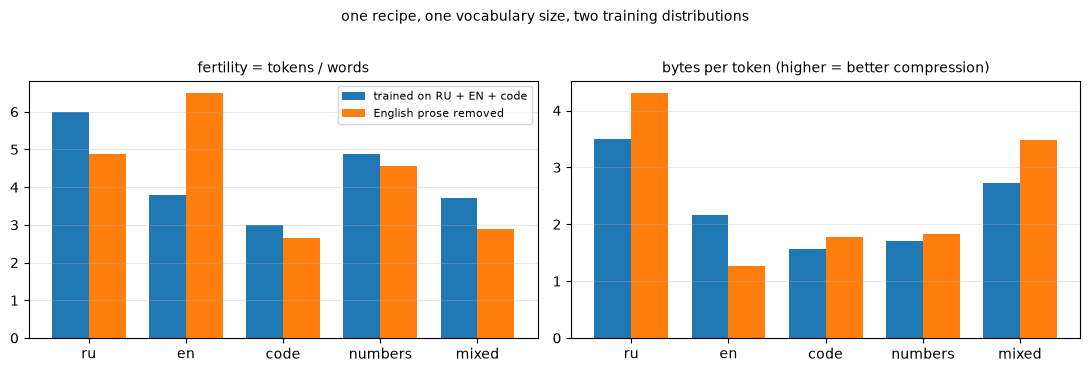

→ out\01_tokenizer_recap.png


In [3]:
TRAIN_TEXTS = [
    "Градиентный спуск обновляет параметры модели по направлению антиградиента.",
    "Матрица внимания связывает запросы с ключами и агрегирует значения.",
    "Вероятность события оценивается частотой на большой независимой выборке.",
    "Токенизатор переводит строку в последовательность целых идентификаторов.",
    "Gradient descent updates model parameters using the negative gradient.",
    "The attention matrix connects queries to keys and aggregates values.",
    "A tokenizer maps text into a sequence of integer identifiers.",
    "Validation loss must be measured on held-out data.",
    "def mean(xs): return sum(xs) / len(xs)",
    "for batch in loader: loss = model(**batch).loss",
    "Проверьте tensor.shape перед вызовом model.forward().",
    "Размеры hidden state: batch=8, sequence=2048, width=4096.",
]
ENGLISH_PROSE = {4, 5, 6, 7}

EVAL_SLICES = {
    "ru": "Градиентный спуск минимизирует функцию потерь последовательными обновлениями параметров.",
    "en": "Gradient descent minimizes the loss function through successive parameter updates.",
    "code": "def variance(xs): return sum((x - sum(xs) / len(xs)) ** 2 for x in xs) / len(xs)",
    "numbers": "Размер матрицы 4096×11008, learning rate равен 0.000125.",
    "mixed": "Проверьте tensor.shape перед model.forward() и затем вызовите backward().",
}


def train_byte_bpe(texts, vocab_size=VOCAB_SIZE):
    tok = Tokenizer(models.BPE(unk_token="<unk>"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    tok.train_from_iterator(texts, trainers.BpeTrainer(vocab_size=vocab_size, min_frequency=1,
                                                       special_tokens=SPECIAL_TOKENS, show_progress=False))
    return tok


def metrics(tok, text):
    n = len(tok.encode(text).ids)
    words = max(1, len(re.findall(r"\w+", text)))
    return n, round(n / words, 2), round(len(text.encode("utf-8")) / n, 2)


tok_full = train_byte_bpe(TRAIN_TEXTS)
tok_no_en = train_byte_bpe([t for i, t in enumerate(TRAIN_TEXTS) if i not in ENGLISH_PROSE])

print(f"{'slice':<9}{'tokens':>8}{'fertility':>11}{'bytes/tok':>11}   |{'tokens':>8}{'fertility':>11}{'bytes/tok':>11}")
print(f"{'':<9}{'— trained on RU + EN + code —':^30}   |{'— English prose removed —':^30}")
rows = {}
for name, text in EVAL_SLICES.items():
    a, b = metrics(tok_full, text), metrics(tok_no_en, text)
    rows[name] = (a, b)
    print(f"{name:<9}{a[0]:>8}{a[1]:>11}{a[2]:>11}   |{b[0]:>8}{b[1]:>11}{b[2]:>11}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
names = list(EVAL_SLICES)
x = range(len(names)); w = 0.38
for a, k, title in ((ax[0], 1, "fertility = tokens / words"), (ax[1], 2, "bytes per token (higher = better compression)")):
    a.bar([i - w / 2 for i in x], [rows[n][0][k] for n in names], w, label="trained on RU + EN + code")
    a.bar([i + w / 2 for i in x], [rows[n][1][k] for n in names], w, label="English prose removed")
    a.set_xticks(list(x)); a.set_xticklabels(names); a.set_title(title, fontsize=10); a.grid(axis="y", alpha=.3)
ax[0].legend(fontsize=8)
fig.suptitle("one recipe, one vocabulary size, two training distributions", y=1.02, fontsize=10)
fig.tight_layout(); fig.savefig(OUT / "01_tokenizer_recap.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"→ {OUT / '01_tokenizer_recap.png'}")

Takeaways:

1. `ru` against `en` compares two slices under *this* tokenizer. It says nothing about the
   languages themselves;
2. removing four sentences from the training text changed the token counts on every slice, in
   both directions. The tokenizer depends on the data pipeline. Section 05 trains the same
   recipe on the raw, cleaned and mixed corpora and compares their merges;
3. these tables do not show which tokenizer gives a better model. That requires training and a
   comparison in BPB.

---

# 03 — corpus rescue: from 27 raw documents to a training set

A small corpus with planted defects, run through the same stages that FineWeb and DCLM run at
scale:

> forensics → quality policy → exact dedup → near dedup → decontamination → funnel

Extraction from HTML or PDF is assumed done, so we start from text. The corpus has 27
documents. It is not a model of Common Crawl, but it is small enough to read every rejected
document, and reading the rejections is how a filter is checked.

Features and decisions are recorded first and rows are removed last. If rows are dropped
immediately, the rejected documents cannot be inspected afterwards.

Runtime: seconds. Dependencies: `datasets`, `matplotlib`.

In [4]:
from __future__ import annotations

import hashlib
import json
import re
import sys
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from datasets import Dataset, disable_progress_bars

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
disable_progress_bars()

OUT = Path("out")
OUT.mkdir(exist_ok=True)


def show_rows(rows, columns=None):
    rows = list(rows)
    if not rows:
        print("(empty)")
        return
    columns = columns or list(rows[0])
    cells = [[str(r[c]) for c in columns] for r in rows]
    widths = [max(len(str(c)), *(len(row[i]) for row in cells)) for i, c in enumerate(columns)]
    print(" | ".join(str(c).ljust(w) for c, w in zip(columns, widths)))
    print("-+-".join("-" * w for w in widths))
    for row in cells:
        print(" | ".join(v.ljust(w) for v, w in zip(row, widths)))

C:\Users\Roman\llm-course-sketch\local\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Documents and their metadata

One row of the `Dataset` is one document. Three metadata columns that are often confused:

| field | question it answers | example |
|---|---|---|
| `source` | where did this row come from | `wiki`, `repository`, `forum`, `synthetic_v1` |
| `domain` | which bucket of the training *mixture* it belongs to | `ru_edu`, `code`, `en_docs`, `dialogue` |
| `provenance` | how the text was produced | `human`, `synthetic` |

One source can feed several domains. `synthetic` is a provenance, not a domain and not a
quality verdict. The column `planted_issue` records which defect was planted in each document.
A real corpus has no such column; here it is used only to check the filters.

In [5]:
DOCUMENTS = [
    {"id": "ru_math", "domain": "ru_edu", "source": "edu", "provenance": "human", "planted_issue": "good",
     "text": "Теорема Пифагора связывает стороны прямоугольного треугольника: a² + b² = c². Формула позволяет проверить вычисления."},
    {"id": "ru_physics", "domain": "ru_edu", "source": "edu", "provenance": "human", "planted_issue": "good",
     "text": "Импульс замкнутой системы сохраняется. При столкновении сумма векторов импульса до взаимодействия равна сумме после него."},
    {"id": "ru_probability", "domain": "ru_edu", "source": "paper", "provenance": "human", "planted_issue": "good",
     "text": "Для независимых событий вероятность совместного наступления равна произведению вероятностей отдельных событий."},
    {"id": "ru_linear", "domain": "ru_edu", "source": "notes", "provenance": "human", "planted_issue": "good",
     "text": "Сингулярное разложение представляет матрицу как UΣVᵀ и отделяет направления от величин растяжения."},
    {"id": "ru_optim", "domain": "ru_edu", "source": "notes", "provenance": "human", "planted_issue": "good",
     "text": "Условие Армихо проверяет достаточное убывание функции и используется для выбора длины шага в line search."},
    {"id": "unicode", "domain": "ru_edu", "source": "wiki", "provenance": "human", "planted_issue": "normalization",
     "text": "Число １２３ записано full-width символами, а между словами стоит неразрывный пробел. NFKC унифицирует представление."},
    {"id": "code_mean", "domain": "code", "source": "repository", "provenance": "human", "planted_issue": "good",
     "text": "def moving_average(values, window):\n    return [sum(values[i:i+window]) / window for i in range(len(values)-window+1)]"},
    {"id": "code_search", "domain": "code", "source": "repository", "provenance": "human", "planted_issue": "good",
     "text": "def binary_search(xs, value):\n    left, right = 0, len(xs)\n    while left < right:\n        middle = (left + right) // 2"},
    {"id": "code_grad", "domain": "code", "source": "repository", "provenance": "human", "planted_issue": "good",
     "text": "optimizer.zero_grad(set_to_none=True)\nloss.backward()\ntorch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)\noptimizer.step()"},
    {"id": "code_mask", "domain": "code", "source": "docs", "provenance": "human", "planted_issue": "good",
     "text": "labels = input_ids.clone()\nlabels[attention_mask == 0] = -100\nloss = cross_entropy(logits[:, :-1], labels[:, 1:])"},
    {"id": "code_mixed", "domain": "code", "source": "forum", "provenance": "human", "planted_issue": "good_mixed",
     "text": "Ошибка ValueError возникает, когда тип аргумента подходит, но значение недопустимо. Проверьте tensor.shape перед reshape."},
    {"id": "en_accum", "domain": "en_docs", "source": "docs", "provenance": "human", "planted_issue": "good",
     "text": "Gradient accumulation emulates a larger batch by summing gradients over several microbatches before an optimizer update."},
    {"id": "en_attention", "domain": "en_docs", "source": "paper", "provenance": "human", "planted_issue": "good",
     "text": "Causal self-attention restricts every query position to keys at the same or earlier sequence positions."},
    {"id": "en_dataset", "domain": "en_docs", "source": "docs", "provenance": "human", "planted_issue": "good",
     "text": "A dataset transformation should preserve provenance metadata so rejected examples can be audited later."},
    {"id": "en_precision", "domain": "en_docs", "source": "docs", "provenance": "human", "planted_issue": "good",
     "text": "Mixed precision reduces memory traffic while selected reductions remain in higher precision for numerical stability."},
    {"id": "dialogue_lr", "domain": "dialogue", "source": "dialogue", "provenance": "human", "planted_issue": "good",
     "text": "— Почему обучение нестабильно? — Сначала проверь learning rate, gradient norm и данные, затем меняй архитектуру."},
    {"id": "dialogue_data", "domain": "dialogue", "source": "dialogue", "provenance": "human", "planted_issue": "good",
     "text": "— Фильтр удалил половину корпуса. Это хорошо? — Нет, пока мы не открыли удалённые документы и не измерили ошибки."},
    {"id": "dialogue_memory", "domain": "dialogue", "source": "dialogue", "provenance": "human", "planted_issue": "good",
     "text": "— Модель не помещается в память. — Раздели параметры, gradients, optimizer state и activations: решения у них разные."},
    {"id": "ru_math_copy", "domain": "ru_edu", "source": "mirror", "provenance": "human", "planted_issue": "exact_duplicate",
     "text": "Теорема Пифагора связывает стороны прямоугольного треугольника: a² + b² = c². Формула позволяет проверить вычисления."},
    {"id": "ru_math_near", "domain": "ru_edu", "source": "blog", "provenance": "human", "planted_issue": "near_duplicate",
     "text": "Теорема Пифагора связывает стороны прямоугольного треугольника: a² + b² = c². По формуле удобно проверять расчёты."},
    {"id": "code_near", "domain": "code", "source": "mirror", "provenance": "human", "planted_issue": "near_duplicate",
     "text": "def moving_average(values, n):\n    return [sum(values[i:i+n]) / n for i in range(len(values)-n+1)]"},
    {"id": "spam", "domain": "ru_edu", "source": "web", "provenance": "human", "planted_issue": "spam",
     "text": "КАЗИНО БОНУС! Нажмите сюда прямо сейчас, получите миллион рублей, лучшие ставки и гарантированный выигрыш без регистрации."},
    {"id": "boilerplate", "domain": "en_docs", "source": "web", "provenance": "human", "planted_issue": "repetition",
     "text": "Используя сайт, вы соглашаетесь с cookie.\nИспользуя сайт, вы соглашаетесь с cookie.\nИспользуя сайт, вы соглашаетесь с cookie.\nПолитика конфиденциальности."},
    {"id": "too_short", "domain": "dialogue", "source": "web", "provenance": "human", "planted_issue": "short",
     "text": "Подробнее здесь."},
    {"id": "benchmark_leak", "domain": "ru_edu", "source": "answers", "provenance": "human", "planted_issue": "contamination",
     "text": "Контрольный вопрос: чему равно 17 × 19? Правильный ответ: 323. Подробное решение опубликовано вместе с тестом."},
    {"id": "synthetic_slop", "domain": "ru_edu", "source": "synthetic_v1", "provenance": "synthetic", "planted_issue": "style",
     "text": "Важно отметить, что данная тема играет важную роль. В заключение важно подчеркнуть значимость глубокого понимания темы."},
    {"id": "empty", "domain": "en_docs", "source": "web", "provenance": "human", "planted_issue": "empty",
     "text": "   "},
]

raw = Dataset.from_list(DOCUMENTS)
print(raw)
print("domains:", dict(Counter(raw["domain"])))
print("sources:", dict(Counter(raw["source"])))
print("\nthe corpus:\n")
for row in raw:
    print(f"  {row['id']:<16} {row['domain']:<9} {row['planted_issue']:<16} {row['text'][:80].replace(chr(10), ' ⏎ ')}")

Dataset({
    features: ['id', 'domain', 'source', 'provenance', 'planted_issue', 'text'],
    num_rows: 27
})
domains: {'ru_edu': 11, 'code': 6, 'en_docs': 6, 'dialogue': 4}
sources: {'edu': 2, 'paper': 2, 'notes': 2, 'wiki': 1, 'repository': 3, 'docs': 4, 'forum': 1, 'dialogue': 3, 'mirror': 2, 'blog': 1, 'web': 4, 'answers': 1, 'synthetic_v1': 1}

the corpus:

  ru_math          ru_edu    good             Теорема Пифагора связывает стороны прямоугольного треугольника: a² + b² = c². Фо
  ru_physics       ru_edu    good             Импульс замкнутой системы сохраняется. При столкновении сумма векторов импульса 
  ru_probability   ru_edu    good             Для независимых событий вероятность совместного наступления равна произведению в
  ru_linear        ru_edu    good             Сингулярное разложение представляет матрицу как UΣVᵀ и отделяет направления от в
  ru_optim         ru_edu    good             Условие Армихо проверяет достаточное убывание функции и используется для выбора 

## 2. Forensics: features before decisions

`Dataset.map` adds columns; nothing is removed yet. Four interpretable signals, none of which
is a "quality score":

* NFKC-normalized text with whitespace collapsed — the *comparison* form. The original text
  stays in its column: normalization is lossy for code and tables, and the model should be
  trained on the real thing;
* character and word counts;
* a rough script ratio standing in for language ID. In production this is fastText or
  GlotLID with a threshold that is a real decision, not a script counter;
* the largest fraction of the document taken by one repeated line — the cheapest
  boilerplate detector there is.

In [6]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", text)
    return re.sub(r"\s+", " ", text).strip()


def rough_language(text):
    latin = sum("a" <= ch.lower() <= "z" for ch in text)
    cyrillic = sum("а" <= ch.lower() <= "я" or ch.lower() == "ё" for ch in text)
    if cyrillic > 1.5 * latin:
        return "ru"
    if latin > 1.5 * cyrillic:
        return "en"
    return "mixed"


def repeated_line_fraction(text):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    if not lines:
        return 0.0
    top = Counter(lines).most_common(1)[0][1]
    return top / len(lines) if top > 1 else 0.0


def audit_features(row):
    norm = normalize_text(row["text"])
    return {"normalized_text": norm, "characters": len(norm),
            "words": len(re.findall(r"\w+", norm)), "language": rough_language(norm),
            "repeated_line_fraction": repeated_line_fraction(row["text"])}


audited = raw.map(audit_features)
show_rows(sorted(({"id": r["id"], "chars": r["characters"], "lang": r["language"],
                   "repeat": round(r["repeated_line_fraction"], 2), "planted_issue": r["planted_issue"]}
                  for r in audited), key=lambda r: (r["chars"], r["id"])))

u = next(r for r in audited if r["id"] == "unicode")
print("\nNFKC at work on the `unicode` document:")
print("  raw :", repr(u["text"][:40]))
print("  norm:", repr(u["normalized_text"][:40]))

id              | chars | lang  | repeat | planted_issue  
----------------+-------+-------+--------+----------------
empty           | 0     | mixed | 0.0    | empty          
too_short       | 16    | ru    | 0.0    | short          
code_near       | 94    | en    | 0.0    | near_duplicate 
ru_linear       | 98    | ru    | 0.0    | good           
code_search     | 103   | en    | 0.0    | good           
en_attention    | 103   | en    | 0.0    | good           
en_dataset      | 103   | en    | 0.0    | good           
ru_optim        | 105   | ru    | 0.0    | good           
benchmark_leak  | 110   | ru    | 0.0    | contamination  
ru_probability  | 110   | ru    | 0.0    | good           
dialogue_lr     | 112   | ru    | 0.0    | good           
code_mask       | 113   | en    | 0.0    | good           
dialogue_data   | 113   | ru    | 0.0    | good           
code_mean       | 114   | en    | 0.0    | good           
ru_math_near    | 114   | ru    | 0.0    | near_duplicat

## 3. A quality policy, and what it gets wrong

A quality filter is a decision rule over features. Four rules, checked in order; the first
one that fires names the rejection bucket, so the buckets do not overlap and every removed
document has exactly one stated reason.

A filter makes two kinds of mistake:

* **false positive** — a useful document rejected. These are found only by reading the
  rejection buckets;
* **false negative** — a defective document kept. `synthetic_slop` below is one on purpose:
  it is long enough, repeats nothing, contains no banned phrase, and has no content. Surface
  heuristics do not catch it. This is one reason FineWeb-Edu and DCLM use trained quality
  classifiers, which in turn have biases of their own.

In [7]:
QUALITY_POLICY = {"min_characters": 55, "max_repeated_line_fraction": 0.55,
                  "banned_phrases": ["казино бонус", "нажмите сюда прямо сейчас"]}


def quality_decision(row):
    if row["characters"] == 0:
        return {"decision": "reject", "reason": "empty"}
    if row["characters"] < QUALITY_POLICY["min_characters"]:
        return {"decision": "reject", "reason": "short"}
    if row["repeated_line_fraction"] > QUALITY_POLICY["max_repeated_line_fraction"]:
        return {"decision": "reject", "reason": "repeated_lines"}
    lowered = row["normalized_text"].lower()
    if any(p in lowered for p in QUALITY_POLICY["banned_phrases"]):
        return {"decision": "reject", "reason": "spam_phrase"}
    return {"decision": "keep", "reason": "keep"}


labeled = audited.map(quality_decision)
kept = labeled.filter(lambda r: r["decision"] == "keep")
rejected = labeled.filter(lambda r: r["decision"] == "reject")

print("decisions:", dict(Counter(labeled["reason"])))
print("\nthe rejection buckets:")
for r in rejected:
    print(f"  [{r['reason']:<14}] {r['id']:<12} {r['text'][:70].replace(chr(10), ' ⏎ ')!r}")
print("\nplanted issues that SURVIVED the policy:",
      {k: v for k, v in Counter(kept["planted_issue"]).items() if k not in ("good", "good_mixed")})

decisions: {'keep': 23, 'spam_phrase': 1, 'repeated_lines': 1, 'short': 1, 'empty': 1}

the rejection buckets:
  [spam_phrase   ] spam         'КАЗИНО БОНУС! Нажмите сюда прямо сейчас, получите миллион рублей, лучш'
  [repeated_lines] boilerplate  'Используя сайт, вы соглашаетесь с cookie. ⏎ Используя сайт, вы соглашает'
  [short         ] too_short    'Подробнее здесь.'
  [empty         ] empty        '   '

planted issues that SURVIVED the policy: {'normalization': 1, 'exact_duplicate': 1, 'near_duplicate': 2, 'contamination': 1, 'style': 1}


Four documents are rejected, all correctly, but this corpus has an answer key. A real corpus
does not, and the false-positive rate of a policy is estimated by sampling the rejected bucket
and reading it.

## 4. Exact and near deduplication

**Exact dedup** hashes a canonical form. Choosing the canonical form is a policy decision:
lowercase + NFKC erases differences in case, digit width and whitespace. Each of these
normalizations can be wrong for some data, code in particular.

**Near dedup** needs a similarity measure. We use word 3-shingles (the set of all consecutive
word triples) and the Jaccard index. This is the quantity MinHash estimates:

> P[ min_hash(A) = min_hash(B) ] = J(A, B)

LSH then finds *candidate* pairs without comparing all pairs. Neither MinHash nor LSH decides
what counts as a duplicate. The threshold does, and it has to be chosen by hand.

In [8]:
def shingles(text, n=3):
    words = re.findall(r"\w+", text.lower())
    if len(words) < n:
        return {tuple(words)} if words else set()
    return {tuple(words[i:i + n]) for i in range(len(words) - n + 1)}


def jaccard(a, b):
    return len(a & b) / len(a | b) if (a or b) else 1.0


def exact_dedup(ds):
    seen, keep, dups = {}, [], []
    for i, r in enumerate(ds):
        digest = hashlib.sha256(r["normalized_text"].lower().encode()).hexdigest()
        if digest in seen:
            dups.append({"id": r["id"], "duplicate_of": seen[digest]})
        else:
            seen[digest] = r["id"]
            keep.append(i)
    return ds.select(keep), dups


def near_dedup(ds, threshold):
    """Greedy: each document is compared against the representatives kept so far. The result
    depends on the order of rows — a production pipeline has to say which copy is kept."""
    reps, keep, dups = [], [], []
    for i, r in enumerate(ds):
        sig = shingles(r["normalized_text"])
        best_id, best = max(((rid, jaccard(sig, s)) for rid, s in reps), key=lambda t: t[1], default=(None, 0.0))
        if best >= threshold:
            dups.append({"id": r["id"], "duplicate_of": best_id, "jaccard": round(best, 3)})
        else:
            reps.append((r["id"], sig))
            keep.append(i)
    return ds.select(keep), dups


exact_unique, exact_dups = exact_dedup(kept)
print("exact duplicates:", exact_dups)

NEAR_THRESHOLD = 0.35
deduped, near_dups = near_dedup(exact_unique, NEAR_THRESHOLD)
print(f"\nnear duplicates at threshold {NEAR_THRESHOLD}:", near_dups)

print("\nthe same step at three thresholds:")
sweep = []
for t in (0.35, 0.55, 0.80):
    ds_t, d_t = near_dedup(exact_unique, t)
    sweep.append({"threshold": t, "kept": len(ds_t), "removed": len(d_t),
                  "pairs": ", ".join(f"{d['id']}→{d['duplicate_of']} ({d['jaccard']})" for d in d_t) or "—"})
show_rows(sweep)

exact duplicates: [{'id': 'ru_math_copy', 'duplicate_of': 'ru_math'}]

near duplicates at threshold 0.35: [{'id': 'ru_math_near', 'duplicate_of': 'ru_math', 'jaccard': 0.438}]

the same step at three thresholds:
threshold | kept | removed | pairs                       
----------+------+---------+-----------------------------
0.35      | 21   | 1       | ru_math_near→ru_math (0.438)
0.55      | 22   | 0       | —                           
0.8       | 22   | 0       | —                           


`ru_math_near`, a paraphrase of the same theorem, is removed at 0.35 and kept at 0.55. Whether
it is a duplicate depends on the training goal. The threshold should be chosen by looking at
concrete pairs, not by targeting a retention rate.

`code_near` is kept at every threshold. It is the same function with `window` renamed to `n`,
and that rename took the Jaccard from 1.0 down to 0.31: a renamed identifier changes every
shingle it appears in, and in a five-line function that is most of them. Code dedup uses other
canonical forms (identifiers replaced by placeholders, comments stripped, AST hashing), and each
of them raises recall at the price of new false matches.

The full pairwise Jaccard matrix is plotted after the funnel.

## 5. Decontamination

`benchmark_leak` is a good document: a correct answer with a worked solution. It is removed
because it contains a held-out evaluation question, and training on it makes that evaluation
meaningless. This needs a different measure:

> containment C(Q, D) = |Q ∩ D| / |Q|,  Q = shingles of the benchmark item, D = of the document

Containment is asymmetric: a short question fully contained in a long solution has
containment 1 and a small Jaccard. The downside is false positives on short, formulaic
questions. The threshold is therefore fixed before the benchmark score is known, and every hit
is logged with document id, benchmark id, score and policy version.

In [9]:
BENCHMARK = [
    {"id": "arithmetic_17x19", "text": "Контрольный вопрос: чему равно 17 × 19? Правильный ответ: 323."},
    {"id": "heldout_python", "text": "Напишите функцию, вычисляющую медиану списка без сторонних библиотек."},
]
CONTAINMENT_THRESHOLD = 0.60


def contamination_hits(ds, benchmark, threshold):
    bench = [(b["id"], shingles(normalize_text(b["text"]), n=2)) for b in benchmark]
    hits = []
    for r in ds:
        d = shingles(r["normalized_text"], n=2)
        for bid, q in bench:
            score = len(d & q) / len(q)
            if score >= threshold:
                hits.append({"document": r["id"], "benchmark": bid, "containment": round(score, 3),
                             "jaccard": round(jaccard(d, q), 3)})
    return hits


hits = contamination_hits(deduped, BENCHMARK, CONTAINMENT_THRESHOLD)
show_rows(hits)
contaminated = {h["document"] for h in hits}
clean = deduped.filter(lambda r: r["id"] not in contaminated)

document       | benchmark        | containment | jaccard
---------------+------------------+-------------+--------
benchmark_leak | arithmetic_17x19 | 1.0         | 0.571  


The order of stages is quality → dedup → decontamination → mixing. Dedup goes before
decontamination so that one leaked document with a hundred copies is logged once, not a
hundred times. Decontamination goes before mixing so the domain weights are computed on the
data that will actually be trained on.

## 6. The funnel

Two ratios per stage:

* **conditional** retention N_i / N_{i−1}: how much this stage removed;
* **cumulative** retention N_i / N_0: how much of the raw corpus is left.

A large drop by itself says nothing about quality. FineWeb removes most of its input, and each
stage was justified by training models with and without it.

In [10]:
stages = [("raw", raw), ("quality", kept), ("exact dedup", exact_unique),
          ("near dedup", deduped), ("decontamination", clean)]
funnel = []
for i, (name, ds) in enumerate(stages):
    prev = len(stages[i - 1][1]) if i else len(ds)
    funnel.append({"stage": name, "documents": len(ds), "removed here": prev - len(ds),
                   "conditional": round(len(ds) / prev, 3), "cumulative": round(len(ds) / len(raw), 3)})
show_rows(funnel)

counts = [f["documents"] for f in funnel]
assert counts == [27, 23, 22, 21, 20], counts  # the expected path; anything else means the policy or corpus changed
print("\nwhat survived, by domain:", dict(Counter(clean["domain"])))
print("survivors with a planted issue:",
      {r["id"]: r["planted_issue"] for r in clean if r["planted_issue"] not in ("good", "good_mixed")})

stage           | documents | removed here | conditional | cumulative
----------------+-----------+--------------+-------------+-----------
raw             | 27        | 0            | 1.0         | 1.0       
quality         | 23        | 4            | 0.852       | 0.852     
exact dedup     | 22        | 1            | 0.957       | 0.815     
near dedup      | 21        | 1            | 0.955       | 0.778     
decontamination | 20        | 1            | 0.952       | 0.741     

what survived, by domain: {'ru_edu': 7, 'code': 6, 'en_docs': 4, 'dialogue': 3}
survivors with a planted issue: {'unicode': 'normalization', 'code_near': 'near_duplicate', 'synthetic_slop': 'style'}


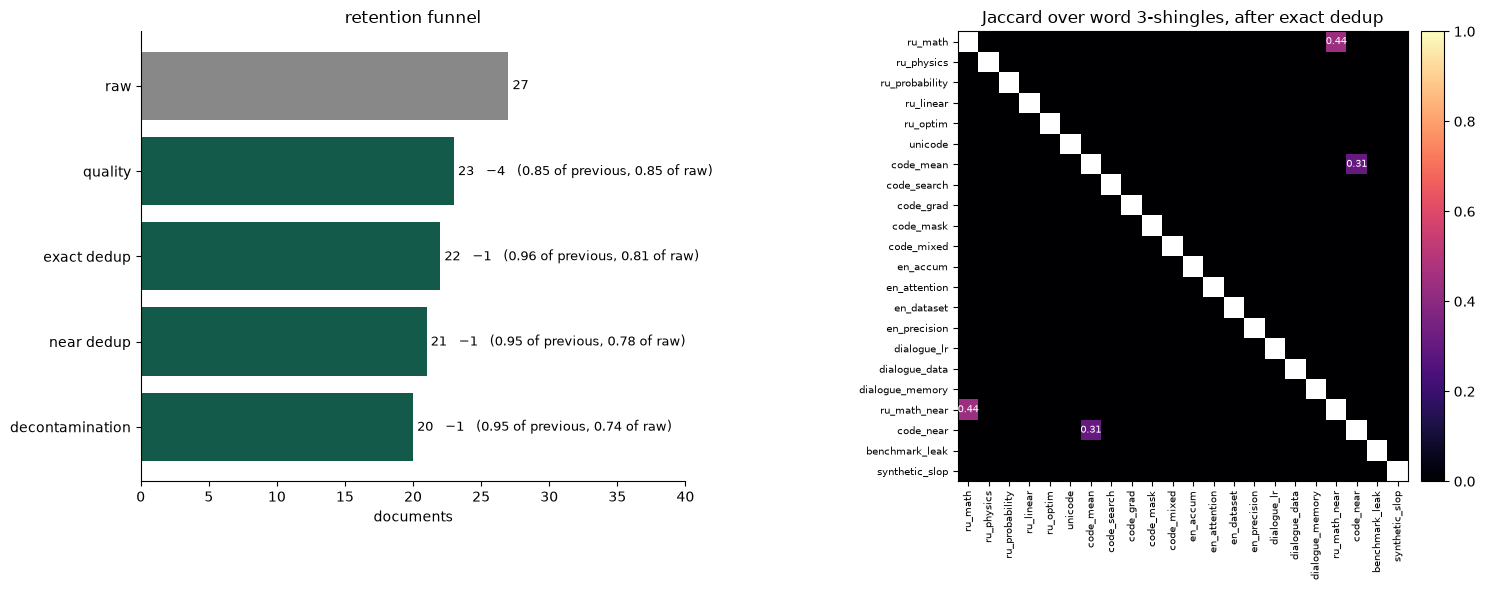

→ out\03_corpus_rescue.png


In [11]:
# ---- the figure: the funnel, and every pair's Jaccard on the post-quality corpus
post_quality = list(exact_unique)
ids = [r["id"] for r in post_quality]
sigs = [shingles(r["normalized_text"]) for r in post_quality]
n = len(ids)
J = [[jaccard(sigs[i], sigs[j]) if i != j else float("nan") for j in range(n)] for i in range(n)]

fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.25]})
names = [f["stage"] for f in funnel]
ax[0].barh(range(len(names))[::-1], counts, color=["#888"] + ["#145a4a"] * 4)
for y, (c, f) in enumerate(zip(counts, funnel)):
    label = f"{c}" if y == 0 else f"{c}   −{f['removed here']}   ({f['conditional']:.2f} of previous, {f['cumulative']:.2f} of raw)"
    ax[0].text(c + 0.3, len(names) - 1 - y, label, va="center", fontsize=9)
ax[0].set_yticks(range(len(names))[::-1]); ax[0].set_yticklabels(names)
ax[0].set_xlim(0, 40); ax[0].set_xlabel("documents"); ax[0].set_title("retention funnel")
ax[0].spines[["top", "right"]].set_visible(False)

im = ax[1].imshow(J, cmap="magma", vmin=0, vmax=1)
ax[1].set_xticks(range(n)); ax[1].set_yticks(range(n))
ax[1].set_xticklabels(ids, rotation=90, fontsize=7); ax[1].set_yticklabels(ids, fontsize=7)
ax[1].set_title("Jaccard over word 3-shingles, after exact dedup")
for i in range(n):
    for j in range(n):
        if i != j and J[i][j] >= 0.2:
            ax[1].text(j, i, f"{J[i][j]:.2f}", ha="center", va="center", fontsize=7,
                       color="white" if J[i][j] < 0.6 else "black")
fig.colorbar(im, ax=ax[1], fraction=0.04, pad=0.02)
fig.tight_layout(); fig.savefig(OUT / "03_corpus_rescue.png", dpi=140)
plt.show()
print(f"→ {OUT / '03_corpus_rescue.png'}")

The heatmap is nearly black: almost every pair of documents is unrelated. Two cells stand out:
`ru_math`/`ru_math_near` at 0.44, the paraphrase that was caught, and `code_mean`/`code_near`
at 0.31, the renamed function that was not. The threshold 0.35 lies between them and was
chosen after looking at these two pairs. With 22 documents all 231 pairs can be compared; at a
billion documents that would be 10^18 comparisons, which is what MinHash-LSH avoids.

## 7. Saving the corpora

Two files are used by the next sections: the raw corpus (a tokenizer is trained on it in
section 05) and the clean corpus with its features (it is mixed in section 04).

In [12]:
KEEP = ["id", "domain", "source", "provenance", "text", "normalized_text", "characters", "words"]
with open(OUT / "03_corpus_raw.jsonl", "w", encoding="utf-8") as f:
    for r in audited:
        f.write(json.dumps({k: r[k] for k in KEEP}, ensure_ascii=False) + "\n")
with open(OUT / "03_corpus_clean.jsonl", "w", encoding="utf-8") as f:
    for r in clean:
        f.write(json.dumps({k: r[k] for k in KEEP}, ensure_ascii=False) + "\n")
print(f"→ {OUT / '03_corpus_raw.jsonl'}  ({len(audited)} documents)")
print(f"→ {OUT / '03_corpus_clean.jsonl'}  ({len(clean)} documents)")

→ out\03_corpus_raw.jsonl  (27 documents)
→ out\03_corpus_clean.jsonl  (20 documents)


## Where this maps onto DataTrove

The stages above are, one to one, the pipeline blocks of
[DataTrove](https://github.com/huggingface/datatrove), the library FineWeb was built with:

| here | DataTrove |
|---|---|
| `raw` from a list | `readers.*` — WARC / JSONL / parquet readers, then `extractors.Trafilatura` |
| `audit_features` | `formatters.*` and the stats writers |
| `quality_decision` | `filters.GopherRepetitionFilter`, `GopherQualityFilter`, `FineWebQualityFilter`, `LanguageFilter` |
| `exact_dedup` / `near_dedup` | `dedup.MinhashDedupSignature → Buckets → Cluster → Filter` — the four-stage MinHash-LSH |
| `contamination_hits` | `filters.URLFilter` + n-gram decontamination against the eval set |

---

# 04 — the data mixture

The clean corpus has four domains. The share of each domain in training is one of the main
hyperparameters of pretraining, and "proportional to size" is also a choice. The weights
encode which abilities the model is supposed to have.

Suppose the target is a **Russian-language technical base model**:

| domain | weight | the ability it is buying |
|---|---|---|
| `ru_edu` | 0.45 | the core subject matter, in the target language |
| `code` | 0.30 | programming, and the formal-reasoning transfer that code is known to give |
| `en_docs` | 0.15 | reading English documentation, which a Russian engineer does daily |
| `dialogue` | 0.10 | a little conversational register — not an imitation of SFT |

Each weight comes with a reason. Without one it is hard to decide later whether to change it.

Runtime: seconds. Dependencies: `matplotlib`. Reads `out/03_corpus_clean.jsonl` — run `03` first.

In [13]:
from __future__ import annotations

import json
import math
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
SEED = 42

MIX_WEIGHTS = {"ru_edu": 0.45, "code": 0.30, "en_docs": 0.15, "dialogue": 0.10}
MIX_SIZE = 120


def show_rows(rows, columns=None):
    rows = list(rows)
    if not rows:
        print("(empty)")
        return
    columns = columns or list(rows[0])
    cells = [[str(r[c]) for c in columns] for r in rows]
    widths = [max(len(str(c)), *(len(row[i]) for row in cells)) for i, c in enumerate(columns)]
    print(" | ".join(str(c).ljust(w) for c, w in zip(columns, widths)))
    print("-+-".join("-" * w for w in widths))
    for row in cells:
        print(" | ".join(v.ljust(w) for v, w in zip(row, widths)))


clean_path = OUT / "03_corpus_clean.jsonl"
if not clean_path.exists():
    raise FileNotFoundError(f"{clean_path} not found — run 03_corpus_rescue.py first")
clean = [json.loads(line) for line in clean_path.open(encoding="utf-8")]
available = Counter(r["domain"] for r in clean)
print(f"{len(clean)} clean documents:", dict(available))

20 clean documents: {'ru_edu': 7, 'code': 6, 'en_docs': 4, 'dialogue': 3}


## 1. A sampler that draws domains, then documents

Two-stage sampling with replacement: pick a domain with probability equal to its weight,
then a uniformly random document from that domain. Large-scale trainers do the same at the
level of shards rather than documents. Per domain we track:

* **target share** — the weight in the config;
* **realized share** — the fraction of drawn documents that came from the domain;
* **repeat factor** — draws from the domain ÷ unique documents in it. Upweighting a small
  domain does not add data, it adds epochs over the same documents.

In [14]:
def sample_mixture(docs, weights, size, seed):
    if not math.isclose(sum(weights.values()), 1.0):
        raise ValueError("weights must sum to one")
    pools = {d: [r for r in docs if r["domain"] == d] for d in weights}
    empty = [d for d, p in pools.items() if not p]
    if empty:
        raise ValueError(f"no documents for domains {empty}")
    rng = random.Random(seed)
    domains = rng.choices(list(weights), weights=list(weights.values()), k=size)
    out = []
    for i, d in enumerate(domains):
        r = dict(rng.choice(pools[d]))
        r["draw"] = i
        out.append(r)
    return out


mixture = sample_mixture(clean, MIX_WEIGHTS, MIX_SIZE, SEED)
drawn = Counter(r["domain"] for r in mixture)
chars = Counter()
for r in mixture:
    chars[r["domain"]] += r["characters"]
total_chars = sum(chars.values())

summary = []
for d, w in MIX_WEIGHTS.items():
    summary.append({"domain": d, "unique docs": available[d], "target share": w,
                    "drawn": drawn[d], "realized doc share": round(drawn[d] / MIX_SIZE, 3),
                    "realized char share": round(chars[d] / total_chars, 3),
                    "repeat factor": round(drawn[d] / available[d], 1)})
show_rows(summary)

domain   | unique docs | target share | drawn | realized doc share | realized char share | repeat factor
---------+-------------+--------------+-------+--------------------+---------------------+--------------
ru_edu   | 7           | 0.45         | 57    | 0.475              | 0.475               | 8.1          
code     | 6           | 0.3          | 37    | 0.308              | 0.309               | 6.2          
en_docs  | 4           | 0.15         | 15    | 0.125              | 0.124               | 3.8          
dialogue | 3           | 0.1          | 11    | 0.092              | 0.093               | 3.7          


**Document share is not token share.** We sample documents, but the model is trained on
tokens, and documents have different lengths. Here the two columns agree to the third decimal
only because every document in this corpus has 100–125 characters. In a real corpus a web page
is a few hundred tokens and a source file or a paper is thousands, so the same weights give a
very different token share. The fix is to budget in tokens, which this sampler does not do;
the `characters` column shows the discrepancy when documents differ in length.

**Repeat factor.** `dialogue` has three documents and a weight of 0.10, so each one is drawn
four times in 120 draws. According to Muennighoff et al.
([2305.16264](https://arxiv.org/abs/2305.16264)), up to about four repetitions the tokens are
worth nearly as much as fresh ones, and by sixteen the benefit is mostly gone. A small
upweighted domain is the first to overfit.

## 2. Sampling noise against repetition

With fewer draws the realized shares deviate more from the target. With more draws the repeat
factor of every small domain grows. Both are controlled by the number of draws.

In [15]:
noise = []
for size in (30, 120, 1200):
    s = sample_mixture(clean, MIX_WEIGHTS, size, SEED)
    c = Counter(r["domain"] for r in s)
    l1 = sum(abs(c[d] / size - w) for d, w in MIX_WEIGHTS.items())
    noise.append({"draws": size, "L1(target, realized)": round(l1, 3),
                  "max repeat factor": round(max(c[d] / available[d] for d in MIX_WEIGHTS), 1),
                  "counts": dict(c)})
show_rows(noise)

draws | L1(target, realized) | max repeat factor | counts                                                       
------+----------------------+-------------------+--------------------------------------------------------------
30    | 0.167                | 2.3               | {'code': 9, 'ru_edu': 16, 'en_docs': 4, 'dialogue': 1}       
120   | 0.067                | 8.1               | {'code': 37, 'ru_edu': 57, 'en_docs': 15, 'dialogue': 11}    
1200  | 0.028                | 74.9              | {'code': 377, 'ru_edu': 524, 'en_docs': 179, 'dialogue': 120}


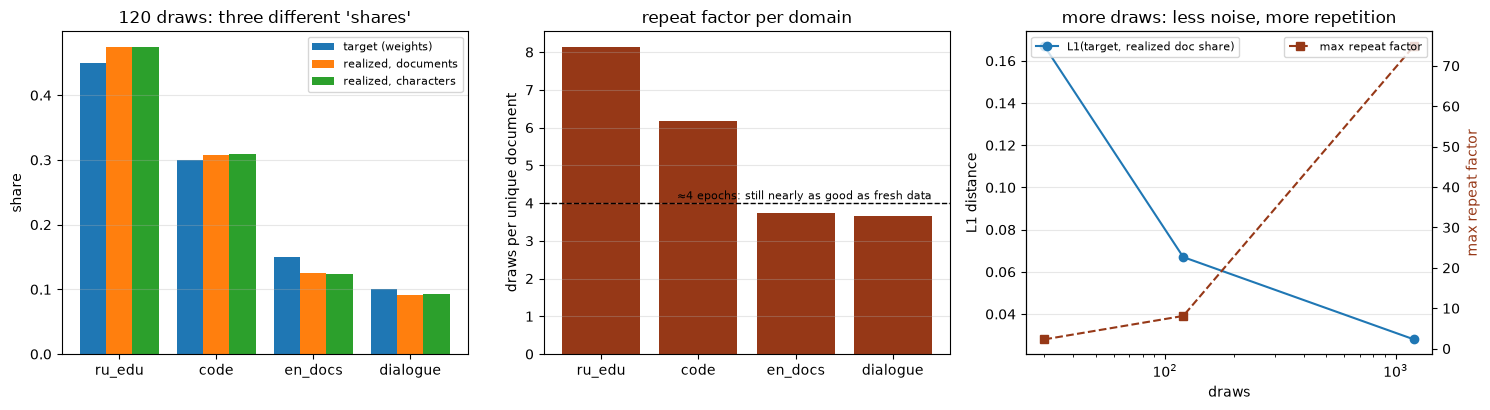

→ out\04_data_mixture.png


In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
doms = list(MIX_WEIGHTS)
x = range(len(doms))
w = 0.27
ax[0].bar([i - w for i in x], [MIX_WEIGHTS[d] for d in doms], w, label="target (weights)")
ax[0].bar([i for i in x], [drawn[d] / MIX_SIZE for d in doms], w, label="realized, documents")
ax[0].bar([i + w for i in x], [chars[d] / total_chars for d in doms], w, label="realized, characters")
ax[0].set_xticks(list(x)); ax[0].set_xticklabels(doms); ax[0].set_ylabel("share")
ax[0].set_title(f"{MIX_SIZE} draws: three different 'shares'"); ax[0].legend(fontsize=8)

ax[1].bar(doms, [drawn[d] / available[d] for d in doms], color="#963817")
ax[1].axhline(4, ls="--", c="k", lw=1); ax[1].text(3.4, 4.1, "≈4 epochs: still nearly as good as fresh data", ha="right", fontsize=8)
ax[1].set_ylabel("draws per unique document"); ax[1].set_title("repeat factor per domain")

sizes = [n["draws"] for n in noise]
ax[2].plot(sizes, [n["L1(target, realized)"] for n in noise], "o-", label="L1(target, realized doc share)")
ax[2].set_xscale("log"); ax[2].set_xlabel("draws"); ax[2].set_ylabel("L1 distance")
ax2 = ax[2].twinx()
ax2.plot(sizes, [n["max repeat factor"] for n in noise], "s--", c="#963817", label="max repeat factor")
ax2.set_ylabel("max repeat factor", color="#963817")
ax[2].set_title("more draws: less noise, more repetition")
ax[2].legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
for a in ax:
    a.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "04_data_mixture.png", dpi=140)
plt.show()
print(f"→ {OUT / '04_data_mixture.png'}")

## 3. How the weights get chosen at scale

Nothing above shows that 0.45 is the right weight. Three ways to choose weights:

1. **manual ablations** — change one weight, train a proxy model, compare held-out NLL
   *per domain*. The average loss of the mixture hides a regression in any single domain,
   so the per-domain suite is the metric, not the mean;
2. **DoReMi** ([2305.10429](https://arxiv.org/abs/2305.10429)) — group-DRO on a small
   proxy: upweight the domains where the proxy lags a reference model the most;
3. **RegMix** ([2407.01492](https://arxiv.org/abs/2407.01492)) — train many small models on
   random mixtures, fit a regression from weights to loss, optimize the regression.

Both automatic methods find the weights on a proxy model, and the transfer to the full model
is imperfect. The final check is the per-domain held-out loss of the real run.

## 4. Synthetic data in the mixture

`provenance = synthetic` describes how the text was produced, not its quality. The
`synthetic_slop` document in section 03 is an example of synthetic text without any record of
how it was generated. A synthetic source should have at least the following before it enters
the mixture:

1. seed documents or a formal topic spec — what the generation was conditioned on;
2. generator model, prompt version, decoding parameters, seed — all fixed and logged;
3. a prompt that demands a genre, a language, a length and a checkable structure, not
   "write a high-quality text";
4. deterministic validators: it parses, it is the right language, the code runs, the
   answer checks;
5. dedup of the synthetic set against itself, against the seeds, against train and eval;
6. a hand-read sample of the failures, and a **cap on the share** of the source in the mix;
7. the acceptance metric is held-out loss and abilities of the trained model — never the
   score of the same classifier that filtered the corpus.

## 5. Saving the mixture

Section 05 trains a tokenizer on this mixture, so the 120 drawn documents are written to a file.

In [17]:
with open(OUT / "04_mixture.jsonl", "w", encoding="utf-8") as f:
    for r in mixture:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
print(f"→ {OUT / '04_mixture.jsonl'}  ({len(mixture)} draws, {len({r['id'] for r in mixture})} distinct documents)")

→ out\04_mixture.jsonl  (120 draws, 20 distinct documents)


---

# 05 — raw, clean, mixed: the same BPE recipe on three corpora

Section 01 trained one recipe on two corpora. Here three tokenizers are compared on the same
five slices, and they differ only in the text they were trained on:

| tokenizer | trained on | from |
|---|---|---|
| `raw` | all 27 documents, defects included | before the funnel |
| `clean` | the 20 survivors | after the funnel |
| `mixed` | 120 draws from the weighted mixture | the mixture |

Same normalizer, same pre-tokenizer, same special tokens, same vocabulary size.

Runtime: seconds. Dependencies: `tokenizers`, `matplotlib`. Reads three files from `out/` —
run `03` and `04` first.

In [18]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from tokenizers import Tokenizer, decoders, models, normalizers, pre_tokenizers, trainers

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

SPECIAL_TOKENS = ["<pad>", "<unk>", "<bos>", "<eos>"]
VOCAB_SIZE = 360


def show_rows(rows, columns=None):
    rows = list(rows)
    if not rows:
        print("(empty)")
        return
    columns = columns or list(rows[0])
    cells = [[str(r[c]) for c in columns] for r in rows]
    widths = [max(len(str(c)), *(len(row[i]) for row in cells)) for i, c in enumerate(columns)]
    print(" | ".join(str(c).ljust(w) for c, w in zip(columns, widths)))
    print("-+-".join("-" * w for w in widths))
    for row in cells:
        print(" | ".join(v.ljust(w) for v, w in zip(row, widths)))


def load_jsonl(name):
    p = OUT / name
    if not p.exists():
        raise FileNotFoundError(f"{p} not found — run 03_corpus_rescue.py and 04_data_mixture.py first")
    return [json.loads(line) for line in p.open(encoding="utf-8")]


CORPORA = {"raw": [r["text"] for r in load_jsonl("03_corpus_raw.jsonl")],
           "clean": [r["text"] for r in load_jsonl("03_corpus_clean.jsonl")],
           "mixed": [r["text"] for r in load_jsonl("04_mixture.jsonl")]}
for k, v in CORPORA.items():
    print(f"{k:<6} {len(v):>4} texts  {sum(len(t.encode('utf-8')) for t in v):>6} bytes")

raw      27 texts    4349 bytes
clean    20 texts    3217 bytes
mixed   120 texts   20280 bytes


The three training sets are **not the same size**. `mixed` is the largest because it repeats
documents, and `clean` is the smallest because seven documents were dropped. A larger training
text at a fixed vocabulary size is a confounder in the comparison below (see also section 07).

In [19]:
def train_byte_bpe(texts, vocab_size=VOCAB_SIZE):
    tok = Tokenizer(models.BPE(unk_token="<unk>"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, min_frequency=1,
                                  special_tokens=SPECIAL_TOKENS, show_progress=False)
    tok.train_from_iterator(texts, trainer=trainer)
    return tok


tokenizers = {name: train_byte_bpe(texts) for name, texts in CORPORA.items()}

## 1. Where the merge budget went

Each tokenizer has a hundred merges. The merges that `raw` has and `clean` does not were spent
on text that the funnel removed.

In [20]:
def merged_symbols(tok):
    """Vocabulary entries that are neither bytes nor special tokens — i.e. produced by merges.
    Byte-level BPE stores them in its own byte alphabet; decode each back to readable text."""
    dec = decoders.ByteLevel()
    out = {}
    for token, idx in tok.get_vocab().items():
        if token in SPECIAL_TOKENS or idx < len(SPECIAL_TOKENS) + 256:
            continue
        text = dec.decode([token])
        if "�" not in text:          # skip merges that end mid-character; they are not readable
            out[text] = idx
    return out


vocab = {name: merged_symbols(tok) for name, tok in tokenizers.items()}
only_raw = sorted(set(vocab["raw"]) - set(vocab["clean"]), key=len, reverse=True)
only_clean = sorted(set(vocab["clean"]) - set(vocab["raw"]), key=len, reverse=True)
only_mixed = sorted(set(vocab["mixed"]) - set(vocab["clean"]), key=len, reverse=True)
print("merges RAW has and CLEAN does not:", " ".join(repr(s) for s in only_raw[:14]))
print("merges CLEAN has and RAW does not:", " ".join(repr(s) for s in only_clean[:14]))
print("merges MIXED has and CLEAN does not:", " ".join(repr(s) for s in only_mixed[:14]))

merges RAW has and CLEAN does not: ' треуголь' 'optimizer' 'реуголь' 'спользу' 'window' ' прямо' 'еуголь' 'optimi' 'ользу' 'орема' 'орму' ' рав' '\n   ' 'ност'
merges CLEAN has and RAW does not: ' optimizer' ' gradient' ' window' ' провер' ' right' 'labels' 'ition' 'abels' 'чение' 'sion' 'loss' 'aver' ' whi' 'ляет'
merges MIXED has and CLEAN does not: ' представ' 'optimizer' 'timizer' ' равна' ' while' ' отде' 'mizer' ' пред' ' left' ' рав' 'tion' 'arch' 'hape' 'став'


In the first line, `raw` spent merges on the cookie banner (`спользу`, `сог`: the boilerplate
document repeats one line three times, so its words are among the most frequent pairs) and on
`треуголь`, `орема`: the Pythagoras sentence appears in the raw corpus three times (original,
exact copy, paraphrase). `clean` spent the same merges on `gradient`, `optimizer`, `провер`.
Duplicates affect a tokenizer the same way they affect a model: they act as extra epochs on
the duplicated text.

## 2. The five slices, three times

In [21]:
EVAL_SLICES = {
    "ru": "Градиентный спуск минимизирует функцию потерь последовательными обновлениями параметров.",
    "en": "Gradient descent minimizes the loss function through successive parameter updates.",
    "code": "def variance(xs): return sum((x - sum(xs) / len(xs)) ** 2 for x in xs) / len(xs)",
    "numbers": "Размер матрицы 4096×11008, learning rate равен 0.000125.",
    "mixed": "Проверьте tensor.shape перед model.forward() и затем вызовите backward().",
}


def word_units(text):
    return max(1, len(re.findall(r"\w+", text)))


def preview(text, encoding, limit=10):
    """Tokens mapped back to character spans; overlapping spans (byte-level splits) are merged,
    and `×k` means that stretch of text took k tokens."""
    groups = []
    for start, end in encoding.offsets:
        if end <= start:
            continue
        if groups and start < groups[-1][1]:
            groups[-1][1] = max(groups[-1][1], end)
            groups[-1][2] += 1
        else:
            groups.append([start, end, 1])
    return " ".join(repr(text[s:e].replace(" ", "␠")) + (f"×{k}" if k > 1 else "")
                    for s, e, k in groups[:limit]) + (" …" if len(groups) > limit else "")


rows = []
tokens = {name: {} for name in tokenizers}
for name, tok in tokenizers.items():
    for sl, text in EVAL_SLICES.items():
        enc = tok.encode(text)
        tokens[name][sl] = len(enc.ids)
        rows.append({"tokenizer": name, "slice": sl, "tokens": len(enc.ids),
                     "fertility": round(len(enc.ids) / word_units(text), 2),
                     "bytes/token": round(len(text.encode("utf-8")) / len(enc.ids), 2),
                     "preview": preview(text, enc)})
show_rows(rows)

print("\ntokens per slice, relative to the RAW tokenizer (below 1.0 = fewer tokens = better compression):")
show_rows([{"slice": sl, **{name: round(tokens[name][sl] / tokens["raw"][sl], 2) for name in ("clean", "mixed")}}
           for sl in EVAL_SLICES])

tokenizer | slice   | tokens | fertility | bytes/token | preview                                            
----------+---------+--------+-----------+-------------+----------------------------------------------------
raw       | ru      | 63     | 7.88      | 2.67        | 'Г'×2 'р' 'ад'×2 'и' 'е' 'н' 'т' 'ный' '␠с' 'пу' … 
raw       | en      | 53     | 5.3       | 1.55        | 'G' 'rad' 'ient' '␠' 'd' 'es' 'c' 'ent' '␠m' 'in' …
raw       | code    | 59     | 3.47      | 1.36        | 'de' 'f' '␠' 'v' 'ar' 'i' 'an' 'c' 'e' '(' …       
raw       | numbers | 44     | 4.89      | 1.7         | 'Р'×2 'аз' 'м' 'ер' '␠м' 'ат' 'р' 'и' 'ц' 'ы' …    
raw       | mixed   | 47     | 4.7       | 2.15        | 'П'×2 'р' 'овер' 'ь' 'т' 'е' '␠t' 'en' 's' 'or' …  
clean     | ru      | 61     | 7.62      | 2.75        | 'Г'×2 'р' 'ад'×2 'и' 'е' 'нт' 'ны' 'й' '␠с' 'пу' … 
clean     | en      | 51     | 5.1       | 1.61        | 'G' 'rad' 'ient' '␠' 'd' 'es' 'c' 'ent' '␠m' 'in' …
clean     | code   

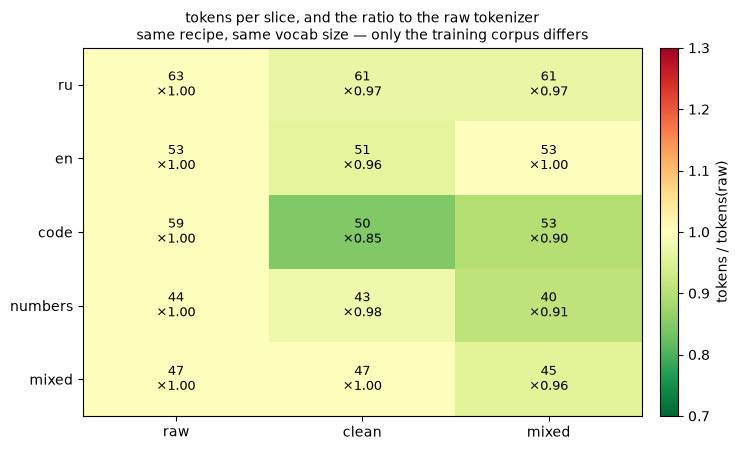

→ out\05_tokenizer_vs_data.png


In [22]:
names = list(tokenizers)
slices = list(EVAL_SLICES)
rel = [[tokens[n][s] / tokens["raw"][s] for n in names] for s in slices]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
im = ax.imshow(rel, cmap="RdYlGn_r", vmin=0.7, vmax=1.3, aspect="auto")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names)
ax.set_yticks(range(len(slices))); ax.set_yticklabels(slices)
for i, s in enumerate(slices):
    for j, n in enumerate(names):
        ax.text(j, i, f"{tokens[n][s]}\n×{rel[i][j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("tokens per slice, and the ratio to the raw tokenizer\nsame recipe, same vocab size — only the training corpus differs", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="tokens / tokens(raw)")
fig.tight_layout(); fig.savefig(OUT / "05_tokenizer_vs_data.png", dpi=140)
plt.show()
print(f"→ {OUT / '05_tokenizer_vs_data.png'}")

## 3. What can and cannot be concluded

The merge budget moved away from junk and toward what the mixture upweighted, and the token
counts on the slices changed, not all in the same direction. Compared with `clean`, `mixed`
gained on `numbers` and on the mixed sentence and lost on `code`, because the mixture repeats
the long Russian documents and the code documents are short. Improving on one slice and
getting worse on another is the normal result of changing the data.

This does **not** show that any of the three tokenizers gives a better model. The corpora
differ in size, the evaluation is five sentences, and compression is not loss. A defensible
conclusion has the form: "cleaning moved N tokens from slice X to slice Y at a fixed
vocabulary; whether that helps the model has to be checked by training and comparing BPB."

---

# 06 — what junk in the data does to the model

Sections 03–05 looked at filtering from the data side. Here we train on data that was not
filtered and look at the models. Four tiny language models with the same architecture, seed,
number of steps and tokens differ only in the training corpus. One is trained on clean
technical text only. The other three are trained on the same clean text with **40% of the
bytes replaced by one kind of junk** that a filter should have removed: SEO spam, license
boilerplate, or forum noise with quotes and repeats. Each model has its own byte-level BPE
tokenizer trained on its own corpus, as in a real run.

We compare the models in two ways:

1. **generations** — what each model produces, and which traces of the junk are visible in it;
2. **evaluation** — perplexity and bits per byte on two evaluation sets. The rankings by these
   metrics disagree, and each disagreement has a specific cause.

All corpora are generated from small grammars, so nothing is downloaded. They are in English
so that the artifacts are easy to read; nothing below depends on the language. Runtime: about
1.5 minutes on a CPU (four trainings). Dependencies: `torch`, `tokenizers`, `matplotlib`.

In [23]:
from __future__ import annotations

import json
import math
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer, decoders, models, normalizers, pre_tokenizers, trainers

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

SEED = 42
TRAIN_BYTES = 320_000        # every training corpus has the same size in bytes
JUNK_SHARE = 0.40            # share of the bytes replaced by junk in the three contaminated corpora
VOCAB_SIZE = 512
BLOCK, BATCH, STEPS, LR = 64, 32, 700, 3e-3
N_LAYER, N_HEAD, N_EMBD = 2, 4, 128

## 1. Four ingredients

The clean text is generated by a small grammar of sentences about training language models.
The three kinds of junk are also grammars, each modelled on a common failure of web pipelines:

* **SEO spam** — keyword stuffing, "buy now", the same product name ten times per page;
* **license boilerplate** — MIT and Apache headers copied verbatim with only the year and the
  holder changed, the most duplicated text in code corpora;
* **forum noise** — quoted replies, `+1`, `same here`, signatures, the same post re-posted.

Below: the clean grammar and one example document. Examples of the junk are printed in section 4.

In [24]:
_MODELS = ["the 125M model", "a 350M model", "the baseline", "the 1.3B run", "our smallest model", "the proxy model"]
_DATA = ["Common Crawl", "the filtered web corpus", "the code subset", "the arXiv slice",
         "the Wikipedia dump", "the forum crawl", "the deduplicated corpus", "the Russian textbook set"]
_STAGES = ["language identification", "exact deduplication", "near deduplication", "quality filtering",
           "decontamination", "domain mixing", "tokenizer training", "PII masking"]
_OPTS = ["AdamW", "SGD with momentum", "Muon", "Adam", "Lion"]
_METRICS = ["validation loss", "bits per byte", "perplexity", "downstream accuracy", "training loss"]
_DOMAINS = ["code", "dialogue", "the web domain", "mathematics", "English documentation", "Russian prose"]
_BENCH = ["GSM8K", "MMLU", "HellaSwag", "the held-out set", "HumanEval"]

CLEAN_TEMPLATES = [
    "{M} was trained on {n} billion tokens from {D} with a batch of {b} sequences.",
    "After {S}, {D} shrank by {p} percent and the {X} improved by {s} nats.",
    "{S} runs before {S2}; reversing the order changes what the model memorizes.",
    "The tokenizer was retrained on {D}, which changed the {X} without changing the text.",
    "Per-token perplexity cannot be compared across tokenizers; bits per byte can.",
    "A near-duplicate is a document whose Jaccard similarity to another exceeds {t}.",
    "{O} keeps {k} buffers per parameter, so the optimizer state costs {k4} bytes per weight.",
    "The learning rate warmed up for {w} steps and decayed to {p} percent of its peak.",
    "Raising the weight of a small domain does not add data; it adds epochs.",
    "Held-out {X} was measured on {n2} documents that never entered the training set.",
    "Gradient norms were clipped at {c}, which removed the loss spikes seen at step {st}.",
    "{M} reached a {X} of {v} after {st} steps on {D}.",
    "Contamination was checked with n-gram containment against {B} before the final run.",
    "Documents shorter than {l} characters were rejected; the rejection bucket was read by hand.",
    "Mixed precision keeps the master weights in float32 and the matmuls in bfloat16.",
    "The quality classifier prefers textbook register and rejects conversational text.",
    "Sequence length was {T} tokens and attention took {p} percent of the step time.",
    "Each ablation held the tokenizer, the seed and the number of steps fixed; only the data changed.",
    "Synthetic text passed the same classifier it was filtered with, which proves nothing.",
    "Repeating {D} for {e} epochs was almost as good as fresh tokens, up to four epochs.",
    "The mixture assigned {p} percent to {G} because the target is a technical assistant.",
    "Exact duplicates were removed by hashing the normalized text; near duplicates by MinHash.",
    "The embedding table stays on Adam; hidden matrices go to the matrix optimizer.",
    "Loss on {G} regressed while the average improved, which the mixture report must show.",
    "Language identification used fastText with a threshold chosen on a labelled sample.",
    "{O} at a learning rate of {lr} diverged at step {st}; halving it fixed the run.",
    "The rejection bucket for {S} contained {p} percent false positives, mostly {G}.",
    "Bits per byte on {D} was {v} for {M} and {v2} for the baseline.",
]


def clean_doc(rng: random.Random) -> str:
    def fill(t):
        return t.format(M=rng.choice(_MODELS).capitalize(), D=rng.choice(_DATA), S=rng.choice(_STAGES).capitalize(),
                        S2=rng.choice(_STAGES), O=rng.choice(_OPTS), X=rng.choice(_METRICS), G=rng.choice(_DOMAINS),
                        B=rng.choice(_BENCH), n=rng.choice([10, 20, 50, 100, 300, 1000]), b=rng.choice([64, 256, 512, 1024]),
                        p=rng.choice([5, 12, 20, 30, 45, 60]), s=rng.choice(["0.02", "0.05", "0.1", "0.3"]),
                        t=rng.choice(["0.5", "0.7", "0.8", "0.9"]), k=rng.choice([1, 2, 3]), k4=rng.choice([4, 8, 12]),
                        w=rng.choice([500, 1000, 2000]), n2=rng.choice([200, 500, 2000]), c=rng.choice(["1.0", "0.5", "2.0"]),
                        st=rng.choice([1200, 4000, 9000, 30000]), v=rng.choice(["1.21", "1.05", "0.98", "2.4"]),
                        v2=rng.choice(["1.30", "1.12", "1.01", "2.6"]), l=rng.choice([50, 100, 200]),
                        T=rng.choice([512, 2048, 4096, 8192]), e=rng.choice([2, 3, 4]), lr=rng.choice(["3e-4", "1e-3", "6e-4"]))
    return " ".join(fill(rng.choice(CLEAN_TEMPLATES)) for _ in range(rng.randint(3, 5)))


print(clean_doc(random.Random(1)))

Synthetic text passed the same classifier it was filtered with, which proves nothing. The mixture assigned 45 percent to English documentation because the target is a technical assistant. Gradient norms were clipped at 2.0, which removed the loss spikes seen at step 9000.


In [25]:
_PRODUCTS = ["vpn", "laptop", "web hosting", "crypto wallet", "essay writing service", "weight loss pills",
             "car insurance", "online casino", "phone case", "protein powder", "mattress", "air fryer"]
SEO_TEMPLATES = [
    "Best {p} {y} - top {n} {p} deals! Cheap {p}, buy {p} online now. Click here for the best {p} prices.",
    "{P} review: is this the best {p} of {y}? Best {p}, cheapest {p}, {p} discount code, {p} free trial.",
    "Looking for {p}? Our {p} guide covers {p} prices, {p} reviews and {p} coupons. Limited time offer, buy now!",
    "Top {n} reasons to buy {p} today. {p} sale, {p} free shipping, {p} best price guaranteed. Click here!",
    "{p} {p} {p} - cheap {p} near me, {p} online, best {p} {y}. Order now and save {d}% on {p}!",
]


def seo_doc(rng: random.Random) -> str:
    p = rng.choice(_PRODUCTS)
    sents = [t.format(p=p, P=p.capitalize(), y=rng.choice([2023, 2024, 2025]), n=rng.choice([5, 7, 10, 25]),
                      d=rng.choice([20, 30, 50, 70])) for t in rng.sample(SEO_TEMPLATES, rng.randint(2, 4))]
    return " ".join(sents) + f" Tags: {p}, cheap {p}, best {p}, {p} {rng.choice([2024, 2025])}, buy {p}."


_HOLDERS = ["Acme Corp", "The Kubeflow Authors", "Jane Doe", "Widget Labs Ltd", "The Foo Project Contributors",
            "OpenTensor Inc", "Roman Ivanov", "The Bar Foundation", "Example Systems GmbH", "Lin Wei"]
MIT_TEXT = (
    "MIT License\n\nCopyright (c) {y} {h}\n\nPermission is hereby granted, free of charge, to any person obtaining a "
    "copy of this software and associated documentation files (the \"Software\"), to deal in the Software without "
    "restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, "
    "and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to "
    "the following conditions:\n\nThe above copyright notice and this permission notice shall be included in all copies "
    "or substantial portions of the Software.\n\nTHE SOFTWARE IS PROVIDED \"AS IS\", WITHOUT WARRANTY OF ANY KIND, "
    "EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR "
    "PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES "
    "OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION "
    "WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE."
)
APACHE_TEXT = (
    "Copyright {y} {h}\n\nLicensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file "
    "except in compliance with the License. You may obtain a copy of the License at\n\n    "
    "http://www.apache.org/licenses/LICENSE-2.0\n\nUnless required by applicable law or agreed to in writing, software "
    "distributed under the License is distributed on an \"AS IS\" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, "
    "either express or implied. See the License for the specific language governing permissions and limitations under "
    "the License."
)


def license_doc(rng: random.Random) -> str:
    head = rng.choice(["# utils.py", "# setup.py", "// main.go", "/* index.js */", "# train.py", "// config.ts"])
    body = rng.choice([MIT_TEXT, MIT_TEXT, APACHE_TEXT]).format(y=rng.choice(range(2012, 2026)), h=rng.choice(_HOLDERS))
    return head + "\n" + body


_TOPICS = ["loss goes to nan", "tokenizer mismatch after retraining", "cuda out of memory on step 1", "which optimizer for 1B",
           "dedup takes forever", "eval numbers don't match the paper", "chat template adds extra bos"]
_JUNK = ["+1", "same here", "bump", "any update?", "this worked for me thanks", "nvm fixed it", "same issue here",
         "+1 same here", "following", "did you ever solve this?", "bump bump", "^ this"]
_SIGS = ["--\nSent from my iPhone", "--\nJohn, moderator", "-- \nPosted via Tapatalk", "--\nRegards, Alex", "--\nSent from my Galaxy"]


def forum_doc(rng: random.Random) -> str:
    topic = rng.choice(_TOPICS)
    opener = rng.choice(["Re: Re: Re: {t}", "Re: {t}", "[SOLVED] {t}", "{t} - any update?", "Re: Re: {t}"]).format(t=topic)
    quoted = "\n".join("> " + s for s in clean_doc(rng).split(". ")[: rng.randint(1, 2)])
    junk = "\n".join(rng.choice(_JUNK) for _ in range(rng.randint(2, 4)))
    return f"{opener}\n{quoted}\n{junk}\n{rng.choice(_SIGS)}"


GENERATORS = {"clean": clean_doc, "seo": seo_doc, "license": license_doc, "forum": forum_doc}


def build_corpus(shares: dict, n_bytes: int, seed: int) -> list[str]:
    """Documents drawn until each ingredient has filled its share of `n_bytes`, then shuffled.
    Budgeted in bytes, not documents — a license is four times longer than a forum post."""
    rng = random.Random(seed)
    docs = []
    for kind, share in shares.items():
        used = 0
        while used < share * n_bytes:
            d = GENERATORS[kind](rng)
            docs.append(d)
            used += len(d.encode("utf-8"))
    rng.shuffle(docs)
    return docs


RECIPES = {"clean": {"clean": 1.0}}
for junk in ("seo", "license", "forum"):
    RECIPES[f"clean+{junk}"] = {"clean": 1 - JUNK_SHARE, junk: JUNK_SHARE}

corpora = {name: build_corpus(shares, TRAIN_BYTES, seed=SEED + i) for i, (name, shares) in enumerate(RECIPES.items())}
eval_sets = {"eval_clean": build_corpus({"clean": 1.0}, 40_000, seed=1000),
             "eval_web": build_corpus({"clean": 0.6, "seo": 0.4 / 3, "license": 0.4 / 3, "forum": 0.4 / 3}, 40_000, seed=1001)}

# the four models are labelled A–D; the letters fix the order in which they are trained
LABELS = dict(zip("ABCD", random.Random(7).sample(list(RECIPES), 4)))
for name, docs in corpora.items():
    print(f"{name:<14} {len(docs):>5} documents, {sum(len(d.encode()) for d in docs) / 1e3:.0f} kB")
for name, docs in eval_sets.items():
    print(f"{name:<14} {len(docs):>5} documents, {sum(len(d.encode()) for d in docs) / 1e3:.0f} kB")

clean            893 documents, 320 kB


clean+seo        781 documents, 320 kB
clean+license    665 documents, 320 kB
clean+forum     1098 documents, 320 kB
eval_clean       115 documents, 40 kB
eval_web         110 documents, 41 kB


## 2. One tokenizer and one model per corpus

The recipe from section 01 — NFKC → ByteLevel → BPE, vocabulary 512 — trained on each corpus.
Then a two-layer transformer, 0.5M parameters, context 64, trained for the same number of
steps on the same number of tokens, from the same seed. The only thing that differs between
the four rows below is the data.

In [26]:
SPECIAL_TOKENS = ["<pad>", "<unk>", "<bos>", "<eos>"]


def train_byte_bpe(texts, vocab_size=VOCAB_SIZE):
    tok = Tokenizer(models.BPE(unk_token="<unk>"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    tok.train_from_iterator(texts, trainers.BpeTrainer(vocab_size=vocab_size, min_frequency=2,
                                                       special_tokens=SPECIAL_TOKENS, show_progress=False))
    return tok


def to_stream(tok, docs):
    eos = tok.token_to_id("<eos>")
    ids = []
    for d in docs:
        ids.extend(tok.encode(d).ids)
        ids.append(eos)
    return torch.tensor(ids, dtype=torch.long)


class Block(nn.Module):
    def __init__(self, d, nh):
        super().__init__()
        self.nh = nh
        self.qkv, self.o = nn.Linear(d, 3 * d, bias=False), nn.Linear(d, d, bias=False)
        self.up, self.down = nn.Linear(d, 4 * d, bias=False), nn.Linear(4 * d, d, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = (t.view(B, T, self.nh, C // self.nh).transpose(1, 2) for t in self.qkv(F.rms_norm(x, (C,))).split(C, -1))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True).transpose(1, 2).reshape(B, T, C)
        x = x + self.o(y)
        return x + self.down(F.gelu(self.up(F.rms_norm(x, (C,)))))


class TinyGPT(nn.Module):
    def __init__(self, vocab, block=BLOCK, n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD):
        super().__init__()
        self.wte, self.wpe = nn.Embedding(vocab, n_embd), nn.Embedding(block, n_embd)
        self.blocks = nn.ModuleList(Block(n_embd, n_head) for _ in range(n_layer))
        self.head = nn.Linear(n_embd, vocab, bias=False)

    def forward(self, idx, targets=None):
        x = self.wte(idx) + self.wpe(torch.arange(idx.size(1)))
        for b in self.blocks:
            x = b(x)
        logits = self.head(F.rms_norm(x, (x.size(-1),)))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))


def train_model(stream, seed=SEED):
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    model = TinyGPT(VOCAB_SIZE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.95), weight_decay=0.1)
    warmup = 50
    losses = []
    for step in range(STEPS):
        lr = LR * min(1.0, (step + 1) / warmup) * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * step / STEPS)))
        for grp in opt.param_groups:
            grp["lr"] = lr
        starts = torch.randint(0, len(stream) - BLOCK - 1, (BATCH,), generator=g)
        x = torch.stack([stream[s:s + BLOCK] for s in starts])
        y = torch.stack([stream[s + 1:s + BLOCK + 1] for s in starts])
        _, loss = model(x, y)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        losses.append(loss.item())
    return model.eval(), losses


runs = {}
print(f"{'model':<7}{'recipe':<14}{'tokens':>8}{'epochs':>8}{'final loss':>12}{'time':>8}")
for label, recipe in LABELS.items():
    tok = train_byte_bpe(corpora[recipe])
    stream = to_stream(tok, corpora[recipe])
    t0 = time.perf_counter()
    model, losses = train_model(stream)
    epochs = STEPS * BATCH * BLOCK / len(stream)
    runs[label] = {"recipe": recipe, "tok": tok, "model": model, "losses": losses, "tokens": len(stream)}
    print(f"{label:<7}{recipe:<14}{len(stream):>8}{epochs:>8.1f}{sum(losses[-20:]) / 20:>12.3f}{time.perf_counter() - t0:>7.0f}s")

model  recipe          tokens  epochs  final loss    time


A      clean+license   117278    12.2       0.162     58s


B      clean            94217    15.2       0.269     48s


C      clean+seo        94918    15.1       0.231     54s


D      clean+forum     106791    13.4       0.299     52s


## 3. Generations

Three unconditional samples from each model, starting from a document boundary, temperature
0.8, top-k 40, the same seeds for all four. `¶` marks a document boundary emitted by the
model, `⏎` a newline. Each contaminated model reproduces its junk: keyword-stuffed product
reviews, license text, quoted replies and signatures.

In [27]:
@torch.no_grad()
def sample(model, tok, n_tokens=90, temperature=0.8, top_k=40, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    eos = tok.token_to_id("<eos>")
    ids = [eos]
    for _ in range(n_tokens):
        logits, _ = model(torch.tensor([ids[-BLOCK:]]))
        logits = logits[0, -1] / temperature
        v, i = logits.topk(top_k)
        nxt = i[torch.multinomial(F.softmax(v, -1), 1, generator=g)].item()
        ids.append(nxt)
    text = "".join("¶" if t == eos else tok.decode([t]) for t in ids[1:])
    return text.replace("\n", " ⏎ ")


samples = {label: [sample(r["model"], r["tok"], seed=SEED + k) for k in range(3)] for label, r in runs.items()}
for label in "ABCD":
    print(f"\n=== model {label}: {runs[label]['recipe']} ===")
    for k, s in enumerate(samples[label]):
        print(f"  [{k + 1}] {s[:300]}")


=== model A: clean+license ===
  [1] The quality classifier prefers textbook register and rejects conversational text. The mixture assigned 20 percent to code because the target is a technical assistant. Synthetic text passed the same classifier it was filtered with, which proves nothing. Gradient norms were clip
  [2] # setup.py ⏎ MIT License ⏎  ⏎ Copyright (c) 2017 The Foo Project Contributors ⏎  ⏎ Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction
  [3] # setup.py ⏎ MIT License ⏎  ⏎ Copyright (c) 2025 The Foo Project Contributors ⏎  ⏎ Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction

=== model B: clean ===
  [1] The quality classifier prefers textbook register and rejects conversational text. Documents sh

## 4. Measuring the artifacts

One raw document of each junk kind, then two simple detectors applied to the samples above:
counts of signature phrases per model, and the longest run of characters that a sample copies
verbatim from its own training corpus (a memorization measure). A clean sentence is about 100
characters, so a match of that length comes from the grammar; a match of 250 characters means
most of a sample was copied whole. These counters are not quality scores. Each of them would
also have found its junk in the corpus itself, where removing it is cheaper.

In [28]:
SIGNATURES = {"seo": ["buy now", "click here", "best price", "free shipping", "cheap ", "limited time"],
              "license": ["permission is hereby granted", "without warranty", "licensed under the apache",
                          "copyright (c)", "as is", "the software"],
              "forum": ["+1", "same here", "> ", "sent from my", "bump", "re: re:"]}


def longest_verbatim_run(sample, corpus_text):
    """Length in characters of the longest substring of `sample` that occurs verbatim in `corpus_text`."""
    s = sample.replace(" ⏎ ", "\n").replace("¶", "\n")
    best = 0
    for i in range(0, len(s), 3):
        lo, hi = best, len(s) - i
        while lo < hi:                       # binary search on the match length from position i
            mid = (lo + hi + 1) // 2
            if s[i:i + mid] in corpus_text:
                lo = mid
            else:
                hi = mid - 1
        best = max(best, lo)
    return best


for kind in ("seo", "license", "forum"):
    print(f"--- a raw {kind} document ---\n" + GENERATORS[kind](random.Random(3)).replace("\n", " ⏎ ")[:260] + "\n")

print(f"\n{'model':<7}{'recipe':<15}{'seo hits':>9}{'license hits':>13}{'forum hits':>11}{'longest verbatim run':>22}")
pathology = {}
for label, r in runs.items():
    joined = " ".join(samples[label]).lower()
    hits = {kind: sum(joined.count(p) for p in pats) for kind, pats in SIGNATURES.items()}
    corpus_text = "\n".join(corpora[r["recipe"]])
    run = max(longest_verbatim_run(s, corpus_text) for s in samples[label])
    pathology[label] = {**hits, "longest_verbatim_run": run}
    print(f"{label:<7}{r['recipe']:<15}{hits['seo']:>9}{hits['license']:>13}{hits['forum']:>11}{run:>17} chars")

--- a raw seo document ---
crypto wallet crypto wallet crypto wallet - cheap crypto wallet near me, crypto wallet online, best crypto wallet 2025. Order now and save 20% on crypto wallet! Crypto wallet review: is this the best crypto wallet of 2024? Best crypto wallet, cheapest crypto w

--- a raw license document ---
# setup.py ⏎ Copyright 2020 Jane Doe ⏎  ⏎ Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at ⏎  ⏎     http://www.apache.org/licenses/LICENSE-2

--- a raw forum document ---
Re: Re: tokenizer mismatch after retraining ⏎ > Per-token perplexity cannot be compared across tokenizers; bits per byte can ⏎ did you ever solve this? ⏎ nvm fixed it ⏎ +1 ⏎ -- ⏎ Regards, Alex


model  recipe          seo hits license hits forum hits  longest verbatim run
A      clean+license          0            6          0              251 chars
B      clean                  0      

C      clean+seo              2            0          0              185 chars
D      clean+forum            0            0          9              138 chars


## 5. Evaluation

Two evaluation sets that were not part of any training corpus: `eval_clean`, clean text only,
and `eval_web`, the same clean grammar with 40% junk of all three kinds, as an unfiltered web
sample would look. Every token of every document is predicted, with a document boundary as the
first context token. Two units:

* **perplexity per token** — `exp(mean NLL per token)`, with each model's own tokenizer;
* **bits per byte** — `NLL_nats / (bytes · ln 2)`, the same bytes for all four.

In [29]:
@torch.no_grad()
def evaluate(model, tok, docs):
    eos = tok.token_to_id("<eos>")
    n_bytes = len("\n".join(docs).encode("utf-8"))          # the boundary token stands for the newline between documents
    ids = to_stream(tok, docs)
    ids = ids[: (len(ids) // BLOCK) * BLOCK].view(-1, BLOCK)
    x = torch.cat([torch.full((ids.size(0), 1), eos), ids[:, :-1]], 1)
    nll = 0.0
    for i in range(0, ids.size(0), 64):
        logits, _ = model(x[i:i + 64])
        nll += F.cross_entropy(logits.reshape(-1, logits.size(-1)), ids[i:i + 64].reshape(-1), reduction="sum").item()
    n_tok = ids.numel()
    return {"ppl": math.exp(nll / n_tok), "bpb": nll / (n_bytes * math.log(2)), "tok_per_byte": n_tok / n_bytes}


table = {label: {name: evaluate(r["model"], r["tok"], docs) for name, docs in eval_sets.items()} for label, r in runs.items()}
print(f"{'model':<7}{'recipe':<15}{'ppl clean':>10}{'bpb clean':>10}{'tok/byte':>9}   |{'ppl web':>9}{'bpb web':>9}{'tok/byte':>9}")
for label, r in runs.items():
    c, w = table[label]["eval_clean"], table[label]["eval_web"]
    print(f"{label:<7}{r['recipe']:<15}{c['ppl']:>10.2f}{c['bpb']:>10.3f}{c['tok_per_byte']:>9.3f}   |{w['ppl']:>9.2f}{w['bpb']:>9.3f}{w['tok_per_byte']:>9.3f}")

print()
for name in eval_sets:
    for unit in ("ppl", "bpb"):
        order = sorted(runs, key=lambda l: table[l][name][unit])
        print(f"ranking by {unit:<4} on {name:<11}: " + " < ".join(f"{l} ({runs[l]['recipe']})" for l in order))

model  recipe          ppl clean bpb clean tok/byte   |  ppl web  bpb web tok/byte
A      clean+license        1.55     0.223    0.352   |    24.18    1.860    0.405
B      clean                1.57     0.193    0.295   |   451.79    3.611    0.409
C      clean+seo            1.54     0.216    0.349   |    39.03    2.049    0.388
D      clean+forum          1.61     0.216    0.315   |   125.67    2.844    0.408

ranking by ppl  on eval_clean : C (clean+seo) < A (clean+license) < B (clean) < D (clean+forum)
ranking by bpb  on eval_clean : B (clean) < C (clean+seo) < D (clean+forum) < A (clean+license)
ranking by ppl  on eval_web   : A (clean+license) < C (clean+seo) < D (clean+forum) < B (clean)
ranking by bpb  on eval_web   : A (clean+license) < C (clean+seo) < D (clean+forum) < B (clean)


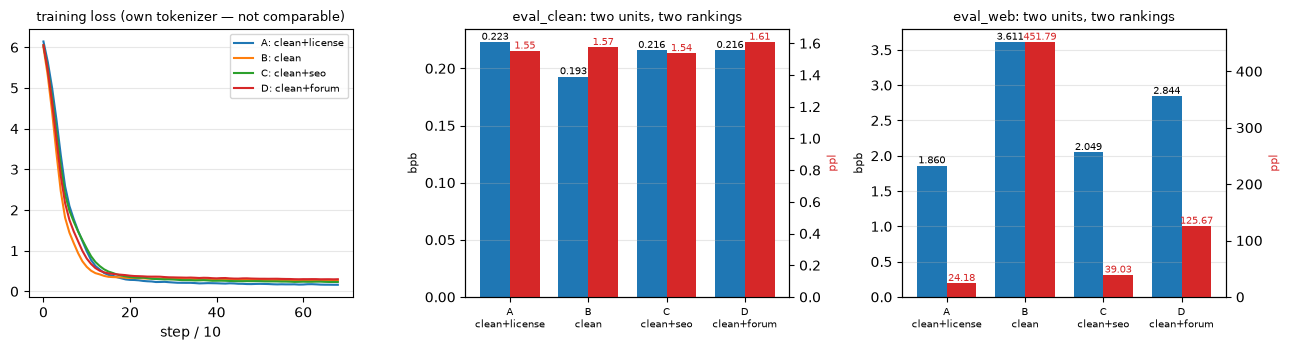

→ out\06_data_detective.png


In [30]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for label, r in runs.items():
    ax[0].plot([sum(r["losses"][i:i + 20]) / 20 for i in range(0, STEPS - 19, 10)], label=f"{label}: {r['recipe']}")
ax[0].set_title("training loss (own tokenizer — not comparable)", fontsize=9); ax[0].set_xlabel("step / 10"); ax[0].legend(fontsize=7)
x = range(4); w = 0.38
for a, name in ((ax[1], "eval_clean"), (ax[2], "eval_web")):
    bpb, ppl = [table[l][name]["bpb"] for l in "ABCD"], [table[l][name]["ppl"] for l in "ABCD"]
    bars = a.bar([i - w / 2 for i in x], bpb, w, label="bits per byte")
    a2 = a.twinx()
    bars2 = a2.bar([i + w / 2 for i in x], ppl, w, color="C3", label="perplexity per token")
    for b, v in zip(bars, bpb):
        a.text(b.get_x() + w / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    for b, v in zip(bars2, ppl):
        a2.text(b.get_x() + w / 2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7, color="C3")
    a.set_xticks(list(x)); a.set_xticklabels([f"{l}\n{runs[l]['recipe']}" for l in "ABCD"], fontsize=7)
    a.set_title(f"{name}: two units, two rankings", fontsize=9); a.set_ylabel("bpb", fontsize=8); a2.set_ylabel("ppl", fontsize=8, color="C3")
for a in ax:
    a.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "06_data_detective.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"→ {OUT / '06_data_detective.png'}")

Results:

1. **Bits per byte on clean text ranks the clean model first**: 0.193 against 0.216–0.223.
   This is the column that measures what filtering gives: the contaminated models spent 40% of
   their tokens on text that the evaluation does not contain.
2. **Perplexity per token gives a different order.** The four perplexities are within 0.07 of
   each other, and the clean model is third. The four tokenizers compress clean text
   differently (`tok/byte`: 0.295 for the clean one, 0.352 for the one trained on 40% licenses,
   whose merges went to `Software` and `WARRANTY`). The junk-trained tokenizers split technical
   text into more, shorter tokens, and short tokens are easier to predict. So a lower
   perplexity here comes with a worse model: perplexities with different tokenizers are not
   comparable.
3. **On `eval_web` the ranking reverses** in both units: the license model is first at 1.86 bpb
   and the clean model last at 3.61. Forty percent of those bytes are junk, the junk is the
   most predictable text in the set, and a model that memorized licenses predicts it almost
   for free. A contaminated evaluation set favours the model trained on the same contamination.
   This is why decontamination is part of the pipeline and why the evaluation set is fixed
   before looking at scores.
4. **The generations agree with `bpb clean`** and also show what went wrong with each
   contaminated model, which the table does not. Three samples per model were enough, and the
   detector is three phrase lists and a substring search. In a real run, samples at every
   checkpoint are cheap, and reading them is a cheap data check.

This experiment does not show the size of any effect: four runs, one seed, half a million
parameters, corpora generated by a grammar. The gaps are real for this setup, but their
magnitudes do not transfer. Section 07 lists what else such an ablation leaves uncontrolled.

## 6. Saving the clean corpus

The clean corpus and its tokenizer are written to `out/` for section 08, which keeps the data
fixed and changes the optimizer. The samples and the tables go to `out/06_detective.json`.

In [31]:
clean_label = next(l for l, r in runs.items() if r["recipe"] == "clean")
(OUT / "06_clean_corpus.txt").write_text("\n".join(corpora["clean"]), encoding="utf-8")
runs[clean_label]["tok"].save(str(OUT / "06_tokenizer_clean.json"))
(OUT / "06_detective.json").write_text(json.dumps({
    "labels": LABELS, "samples": samples, "pathology": pathology, "eval": table,
    "config": {"train_bytes": TRAIN_BYTES, "junk_share": JUNK_SHARE, "vocab": VOCAB_SIZE, "steps": STEPS,
               "batch": BATCH, "block": BLOCK, "n_layer": N_LAYER, "n_embd": N_EMBD}}, indent=1, ensure_ascii=False), encoding="utf-8")
print(f"→ {OUT / '06_clean_corpus.txt'}  ({(OUT / '06_clean_corpus.txt').stat().st_size / 1e3:.0f} kB)")
print(f"→ {OUT / '06_tokenizer_clean.json'}\n→ {OUT / '06_detective.json'}")

→ out\06_clean_corpus.txt  (322 kB)
→ out\06_tokenizer_clean.json
→ out\06_detective.json


---

# 07 — what can go wrong in a data ablation

Section 06 was a data ablation: four runs that differ in one variable. Any ablation can be
checked with four questions:

1. the **treatment** — what was changed between the runs;
2. the **confounders** — what else changed along with it;
3. the **budget** that should be held fixed, and in which unit (steps, tokens, bytes, FLOPs);
4. the **metric** that would expose a problem if there is one.

Section 06 held fixed the architecture, seed, steps, tokens per step and bytes per corpus. It
did not hold fixed:

* the tokenizer: each model trained its own, so the perplexity column is not comparable;
* the number of documents: a license is about four times longer than a forum post, so equal
  bytes means different document counts;
* the number of seeds: one;
* the evaluation set: `eval_clean` is generated by the same grammar as the training text, so it
  measures how well the grammar was learned, not generalization.

A conclusion from an ablation should have the form "the observation supports X under
conditions Y; it does not establish Z".

## Six typical flawed claims

**1. "After cleaning, perplexity went down."** The tokenizer was retrained on the clean corpus,
and the baseline model kept the old one.
*Problem:* per-token perplexity depends on the tokenizer (section 06: the tokenizer trained on
40% licenses gave the lowest perplexity on clean text and the worst bits per byte).
*Fix:* compare in BPB, or keep one tokenizer for both runs.

**2. "Filter A beats filter B."** A kept half as many tokens as B, and both models were trained
for the same number of epochs.
*Problem:* the model on B saw twice as many tokens, so the comparison mixes data quality with
training budget.
*Fix:* train both for the same number of tokens (or FLOPs) and report the repetition that this
implies for the smaller dataset.

**3. "Near-dedup improved the benchmark score."** Overlap with the benchmark was checked only
after training, and only for the deduplicated run.
*Problem:* the baseline may contain benchmark items that dedup happened to remove, and a check
after seeing the score invites choosing a threshold that fits the result (`eval_web` in section
06 is the extreme case: the evaluation set contained the junk, and the junk-trained model won).
*Fix:* decontaminate both runs against the benchmark with a threshold fixed in advance.

**4. "Our Russian tokenizer is better: lower fertility."** Its vocabulary is four times larger
than the one it is compared with.
*Problem:* fertility falls with vocabulary size, and a larger vocabulary costs embedding and
head parameters.
*Fix:* compare at equal vocabulary size, or show the whole compression-vs-vocabulary curve.

**5. "The new mixture improved the average loss."** Per-domain losses were not reported, and
neither was the realized token share of each domain.
*Problem:* the average can improve while one domain gets worse, and the realized shares may
differ from the weights in the config.
*Fix:* report held-out loss per domain and the realized token shares.

**6. "The synthetic source is high quality: the quality classifier accepts it."** It is the
same classifier that was used to filter the corpus.
*Problem:* the source was selected by that classifier, so its score cannot be used to evaluate
it.
*Fix:* evaluate the effect of the source on held-out loss and downstream tasks of a trained
model.

The common failure modes are seed noise, unequal budgets and leakage, plus comparisons in
units that depend on the tokenizer.

## Appendix — three meanings of "packing"

The word is used for three different mechanisms:

1. **Pretraining stream.** Documents are joined with `<eos>` and cut into fixed-length blocks.
   The mask is the plain causal one, so a token can attend across a document boundary. There is
   almost no padding, and some cross-document context that the model has to learn to ignore.
   This is what `to_stream` does in sections 06 and 08.
2. **Document-aware pretraining.** The same blocks, but attention is restricted to the current
   document (block-diagonal causal mask), and position ids may reset per document. This needs
   kernel support: varlen attention with cumulative sequence lengths. OLMo's document masking
   and recent Llama runs use it.
3. **Example packing / padding-free SFT.** Several complete examples are placed into one row
   to remove padding. Boundaries, position ids and loss masks have to be carried along. This
   is a throughput optimization and does not by itself change what attends to what.

A collator with dynamic padding does none of the three.

References: [OLMo `model.py`](https://github.com/allenai/OLMo/blob/main/olmo/model.py)
(document masking) ·
[Transformers: padding-free training](https://huggingface.co/docs/transformers/main/padding_free) ·
[TRL: packing](https://huggingface.co/docs/trl/reducing_memory_usage#packing).

---

# 08 — the optimizer as an algorithm: Adam's coordinates, Muon's directions

SGD → Adam → AdamW, and then Muon, which several large labs adopted in 2025:
`B ← μB + G`, `O = NS₅(B) ≈ UVᵀ`, with the step scaled to match AdamW's RMS. This section
looks at the update rules themselves: what each update is on one gradient of a small model,
and how each optimizer trains on the clean corpus of section 06 (data fixed, optimizer
changed). The systems side (state memory, FLOPs, sharded matrices) is left out.

1. SGD, Adam and AdamW, one function each, with the hand-written Adam checked against `torch.optim`;
2. why per-coordinate scaling: gradient scales across a transformer differ by orders of magnitude;
3. the geometry of one update: Adam against Muon on the same matrix (RMS, cosine, spectrum,
   stable rank);
4. training with four optimizers on the same data, tokenizer and seed, and the cost of a step;
5. which parameters go to Muon and which to AdamW.

Runtime ~1.5 min on CPU. Dependencies: `torch`, `tokenizers`, `matplotlib`. Reads
`out/06_clean_corpus.txt` and `out/06_tokenizer_clean.json` — run 06 first.

Sources: Kingma & Ba, *Adam* ([1412.6980](https://arxiv.org/abs/1412.6980)) · Loshchilov &
Hutter, *Decoupled Weight Decay* ([1711.05101](https://arxiv.org/abs/1711.05101)) · Jordan et
al., [Muon](https://kellerjordan.github.io/posts/muon/) (blog, 2024) · Liu et al., *Muon is
Scalable* ([2502.16982](https://arxiv.org/abs/2502.16982), Moonlight) · Bernstein & Newhouse,
*Old Optimizer, New Norm* ([2409.20325](https://arxiv.org/abs/2409.20325)) · Wen et al.,
*Fantastic Pretraining Optimizers* ([2509.02046](https://arxiv.org/abs/2509.02046)).

In [32]:
from __future__ import annotations

import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

SEED = 42
BLOCK, BATCH, STEPS = 64, 32, 400
LR_ADAM, WD = 3e-3, 0.1            # the same learning rate serves AdamW and Muon: Moonlight's RMS matching is what makes that fair
N_LAYER, N_HEAD, N_EMBD = 2, 4, 128

corpus_path, tok_path = OUT / "06_clean_corpus.txt", OUT / "06_tokenizer_clean.json"
if not corpus_path.exists() or not tok_path.exists():
    raise FileNotFoundError("run 06_data_detective.py first — it writes the clean corpus and its tokenizer to out/")
docs = corpus_path.read_text(encoding="utf-8").split("\n")
tok = Tokenizer.from_file(str(tok_path))
train_docs, heldout_docs = docs[: int(0.9 * len(docs))], docs[int(0.9 * len(docs)):]
EOS = tok.token_to_id("<eos>")


def to_stream(docs):
    ids = []
    for d in docs:
        ids.extend(tok.encode(d).ids)
        ids.append(EOS)
    return torch.tensor(ids, dtype=torch.long)


train_stream, heldout_bytes = to_stream(train_docs), len("\n".join(heldout_docs).encode("utf-8"))
print(f"clean corpus: {len(train_docs)} training documents ({len(train_stream)} tokens), {len(heldout_docs)} held out; vocabulary {tok.get_vocab_size()}")

clean corpus: 803 training documents (84931 tokens), 90 held out; vocabulary 512


## 1. SGD, Adam, AdamW

Every optimizer below is a rule `p ← p − lr · direction(g, state)`. They differ in what
`direction` uses: the gradient, its running mean, the running mean divided coordinate-wise by a
running scale, and in section 3 the gradient as a matrix.

Weight decay appears in two forms. `Adam + L2` adds `wd · p` to the gradient *before* the
moments, so the decay is divided by `√v` like the rest of the gradient: negligible where
gradients are large, and dominant where they are small. `AdamW` shrinks the weight directly by
`lr · wd · p` and leaves the moments alone (Loshchilov & Hutter). This is why the
`weight_decay` arguments of `torch.optim.Adam` and `torch.optim.AdamW` define two different
algorithms. Section 4 runs both with the same value.

In [33]:
@torch.no_grad()
def sgd_momentum_step(p, g, s, lr, momentum=0.9):
    s["buf"] = momentum * s.get("buf", torch.zeros_like(p)) + g
    p.sub_(lr * s["buf"])


@torch.no_grad()
def adam_step(p, g, s, lr, betas=(0.9, 0.95), eps=1e-8, wd=0.0, decoupled=True):
    if wd and not decoupled:
        g = g + wd * p                     # "L2": the decay enters the moments and gets normalized away
    if wd and decoupled:
        p.mul_(1 - lr * wd)                # AdamW: the decay is applied to the weight itself
    s["t"] = s.get("t", 0) + 1
    s["m"] = betas[0] * s.get("m", torch.zeros_like(p)) + (1 - betas[0]) * g
    s["v"] = betas[1] * s.get("v", torch.zeros_like(p)) + (1 - betas[1]) * g * g
    m_hat, v_hat = s["m"] / (1 - betas[0] ** s["t"]), s["v"] / (1 - betas[1] ** s["t"])
    p.sub_(lr * m_hat / (v_hat.sqrt() + eps))


# the hand-written AdamW against the library, five steps on one tensor with random gradients
torch.manual_seed(0)
p_ref = torch.randn(64, 32)
p_ours, state = p_ref.clone(), {}
ref = torch.optim.AdamW([p_ref], lr=1e-2, betas=(0.9, 0.95), eps=1e-8, weight_decay=0.1)
for _ in range(5):
    g = torch.randn(64, 32)
    p_ref.grad = g.clone(); ref.step()
    adam_step(p_ours, g, state, lr=1e-2, wd=0.1, decoupled=True)
print(f"hand-written AdamW vs torch.optim.AdamW after 5 steps: max |Δ| = {(p_ref - p_ours).abs().max():.1e}")

hand-written AdamW vs torch.optim.AdamW after 5 steps: max |Δ| = 2.4e-07


## 2. Why per-coordinate: one gradient, seven tensors, one learning rate

The model of section 06 is trained for 100 steps of AdamW, so that the gradient is realistic
and the Adam state is filled. Then one batch and one backward pass, and per tensor we print the
RMS of the gradient (equal to the RMS of an SGD step at learning rate 1) and the RMS of the step
Adam computes from its state. The SGD step is the gradient times a constant, so it inherits the
scale differences between tensors: a learning rate that suits the embedding rows touched by
the batch is too small for the others, and one that suits the matrices moves the positions too
far. Adam's `m/√v` is a ratio of two quantities with the same units, so its step has roughly the
same size in every tensor. Here the gradient spread is a factor of nine, on a two-layer model
with a norm in front of every matrix; in deep models without such norms it is orders of
magnitude. This is one reason SGD works poorly on transformers, and why one learning rate can
serve the whole model under Adam.

In [34]:
class Block(nn.Module):
    def __init__(self, d, nh):
        super().__init__()
        self.nh = nh
        self.qkv, self.o = nn.Linear(d, 3 * d, bias=False), nn.Linear(d, d, bias=False)
        self.up, self.down = nn.Linear(d, 4 * d, bias=False), nn.Linear(4 * d, d, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = (t.view(B, T, self.nh, C // self.nh).transpose(1, 2) for t in self.qkv(F.rms_norm(x, (C,))).split(C, -1))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True).transpose(1, 2).reshape(B, T, C)
        x = x + self.o(y)
        return x + self.down(F.gelu(self.up(F.rms_norm(x, (C,)))))


class TinyGPT(nn.Module):
    def __init__(self, vocab, block=BLOCK, n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD):
        super().__init__()
        self.wte, self.wpe = nn.Embedding(vocab, n_embd), nn.Embedding(block, n_embd)
        self.blocks = nn.ModuleList(Block(n_embd, n_head) for _ in range(n_layer))
        self.head = nn.Linear(n_embd, vocab, bias=False)

    def forward(self, idx, targets=None):
        x = self.wte(idx) + self.wpe(torch.arange(idx.size(1)))
        for b in self.blocks:
            x = b(x)
        logits = self.head(F.rms_norm(x, (x.size(-1),)))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))


def batches(seed=SEED):
    g = torch.Generator().manual_seed(seed)
    while True:
        starts = torch.randint(0, len(train_stream) - BLOCK - 1, (BATCH,), generator=g)
        yield (torch.stack([train_stream[s:s + BLOCK] for s in starts]),
               torch.stack([train_stream[s + 1:s + BLOCK + 1] for s in starts]))


def lr_at(step, peak, steps=STEPS, warmup=50):
    return peak * min(1.0, (step + 1) / warmup) * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * step / steps)))


def rms(t):
    return t.pow(2).mean().sqrt().item()


torch.manual_seed(SEED)
warm = TinyGPT(tok.get_vocab_size())
warm_opt = torch.optim.AdamW(warm.parameters(), lr=LR_ADAM, betas=(0.9, 0.95), weight_decay=WD)
it = batches()
for step in range(100):
    x, y = next(it)
    _, loss = warm(x, y)
    warm_opt.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(warm.parameters(), 1.0); warm_opt.step()
x, y = next(it)
_, loss = warm(x, y)
warm_opt.zero_grad(set_to_none=True); loss.backward()

print(f"warm model after 100 steps: loss {loss.item():.3f}\n")
print(f"{'tensor':<22}{'shape':<12}{'grad RMS = SGD step at lr 1':>28}{'Adam step RMS at lr 3e-3':>26}")
grad_rms, adam_rms, names = [], [], []
for name, p in warm.named_parameters():
    if name.startswith("blocks.1"):
        continue                                    # second layer looks like the first
    st = warm_opt.state[p]
    m_hat, v_hat = st["exp_avg"] / (1 - 0.9 ** st["step"].item()), st["exp_avg_sq"] / (1 - 0.95 ** st["step"].item())
    a = LR_ADAM * m_hat / (v_hat.sqrt() + 1e-8)
    names.append(name.replace("blocks.0.", "")); grad_rms.append(rms(p.grad)); adam_rms.append(rms(a))
    print(f"{names[-1]:<22}{str(tuple(p.shape)):<12}{grad_rms[-1]:>28.1e}{adam_rms[-1]:>26.1e}")
print(f"\ngradient RMS spans a factor of {max(grad_rms) / min(grad_rms):.0f} across tensors; Adam's step spans a factor of {max(adam_rms) / min(adam_rms):.1f}")

warm model after 100 steps: loss 0.434

tensor                shape        grad RMS = SGD step at lr 1  Adam step RMS at lr 3e-3
wte.weight            (512, 128)                       6.1e-05                   6.8e-04
wpe.weight            (64, 128)                        1.6e-04                   7.5e-04
qkv.weight            (384, 128)                       3.9e-04                   6.8e-04
o.weight              (128, 128)                       5.4e-04                   6.2e-04
up.weight             (512, 128)                       3.5e-04                   6.2e-04
down.weight           (128, 512)                       4.4e-04                   5.8e-04
head.weight           (512, 128)                       4.3e-04                   6.2e-04

gradient RMS spans a factor of 9 across tensors; Adam's step spans a factor of 1.3


## 3. The geometry of one update: Adam against Muon on the same matrix

Take one hidden matrix — the first block's `up` projection, `512 × 128` — and its gradient
`G` from the batch above. Three directions from the same `G`, with momentum and weight decay
switched off so that only the rule is compared:

* **SGD**: `G` itself;
* **Adam, step 1**: `G / (|G| + ε)` — with no history, `m = G` and `√v = |G|`, and the update is
  the sign of the gradient. Adam normalizes *coordinates*;
* **Muon**: `U Vᵀ` from the SVD `G = U Σ Vᵀ` — every singular value set to 1, scaled by
  `0.2·√max(m, n)` so the RMS matches Adam's (Moonlight). Muon normalizes *directions*.

In practice Muon computes `U Vᵀ` with Newton–Schulz iterations instead of an SVD; here we use
the exact SVD. Four numbers per direction: RMS, `cos_F(G, ΔW)`, the normalized spectrum
`σᵢ / σ₁`, and the stable rank `‖X‖²_F / ‖X‖²₂` (1 for a rank-one matrix, `min(m, n)` when
all singular values are equal).

In [35]:
def polar_factor(G):
    """The orthogonal matrix nearest to G — U Vᵀ from its SVD. Exact; Newton–Schulz approximates it."""
    U, S, Vh = torch.linalg.svd(G, full_matrices=False)
    return U @ Vh


def muon_direction(G):
    return polar_factor(G) * (0.2 * math.sqrt(max(G.shape)))


def stable_rank(X):
    s = torch.linalg.svdvals(X)
    return (s.pow(2).sum() / s[0].pow(2)).item()


def cos_f(A, B):
    return ((A * B).sum() / (A.norm() * B.norm())).item()


G = warm.blocks[0].up.weight.grad.detach().clone()
directions = {"SGD: G": G, "Adam, step 1: sign(G)": G / (G.abs() + 1e-8), "Muon: U Vᵀ · 0.2√max(m,n)": muon_direction(G)}
print(f"{'direction':<28}{'RMS':>8}{'cos_F(G, ·)':>13}{'stable rank':>13}{'σ₁/σ_min':>10}")
spectra = {}
for name, D in directions.items():
    s = torch.linalg.svdvals(D)
    spectra[name] = (s / s[0]).numpy()
    print(f"{name:<28}{rms(D):>8.1e}{cos_f(G, D):>13.3f}{stable_rank(D):>13.1f}{(s[0] / s[-1]).item():>10.0f}")
print(f"\nmin(m, n) = {min(G.shape)}: Muon's stable rank is the whole matrix; the gradient's is a handful of directions")

direction                        RMS  cos_F(G, ·)  stable rank  σ₁/σ_min
SGD: G                       3.5e-04        1.000          7.2        33
Adam, step 1: sign(G)        1.0e+00        0.782         12.9         8
Muon: U Vᵀ · 0.2√max(m,n)    2.0e-01        0.736        128.0         1

min(m, n) = 128: Muon's stable rank is the whole matrix; the gradient's is a handful of directions


The gradient of the `512 × 128` matrix has a stable rank of a few: almost all of its energy is
in a handful of singular directions, and SGD steps along those. Adam's sign step changes every
coordinate by the same amount, but it is still an elementwise map: its spectrum is flatter than
that of `G` but not flat, and its stable rank is far from 128. Muon's stable rank is 128 by
construction: directions that are weak in the gradient get the same step as the dominant ones.
This is why its cosine with `G` is the lowest of the three. Bernstein & Newhouse formalize this:
without momentum, Adam is steepest descent when the size of a step is measured by its largest
coordinate, and Muon when it is measured by its largest singular value. Which of the two trains
faster is an empirical question; section 4 is one small experiment on it.

## 4. Training with four optimizers

Four optimizers on the clean corpus with the same tokenizer (so, unlike section 06, per-token
loss is comparable), seed, batches, 400 steps, warmup and cosine schedule. SGD gets a
learning-rate sweep, since a single untuned value would be unfair to it. The Adam variants and
Muon share one learning rate; Moonlight's RMS matching makes that a reasonable default. Held-out
loss is computed on documents not used for training. The optimizer step is timed separately:
here Muon's step includes an SVD of every hidden matrix, which is the cost that Newton–Schulz
is used to avoid.

In [36]:
class HybridMuon:
    """Muon (Nesterov momentum + exact polar factor, Moonlight scaling) on the 2-D weights inside the blocks;
    AdamW on everything else — embeddings, positions, the head."""
    def __init__(self, model, lr=LR_ADAM, wd=WD, momentum=0.95):
        self.muon = [p for n, p in model.named_parameters() if p.ndim == 2 and n.startswith("blocks.")]
        self.adam = torch.optim.AdamW([p for n, p in model.named_parameters() if not (p.ndim == 2 and n.startswith("blocks."))],
                                      lr=lr, betas=(0.9, 0.95), weight_decay=wd)
        self.buf = [torch.zeros_like(p) for p in self.muon]
        self.lr, self.wd, self.mom = lr, wd, momentum
        self.param_groups = self.adam.param_groups + [{"params": self.muon, "lr": lr}]

    @torch.no_grad()
    def step(self):
        self.adam.step()
        lr = self.param_groups[-1]["lr"]
        for p, b in zip(self.muon, self.buf):
            b.mul_(self.mom).add_(p.grad)
            g = p.grad.add(b, alpha=self.mom)
            p.mul_(1 - lr * self.wd).add_(muon_direction(g), alpha=-lr)

    def zero_grad(self, set_to_none=True):
        self.adam.zero_grad(set_to_none=set_to_none)
        for p in self.muon:
            p.grad = None


def make(name, model, lr):
    if name == "SGD + momentum":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    if name == "Adam + L2":
        return torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=WD)     # L2 in the gradient
    if name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=WD)    # decoupled
    return HybridMuon(model, lr=lr)


@torch.no_grad()
def heldout_loss(model):
    ids = to_stream(heldout_docs)
    ids = ids[: (len(ids) // BLOCK) * BLOCK].view(-1, BLOCK)
    x = torch.cat([torch.full((ids.size(0), 1), EOS), ids[:, :-1]], 1)
    nll = sum(F.cross_entropy(model(x[i:i + 64])[0].reshape(-1, tok.get_vocab_size()), ids[i:i + 64].reshape(-1), reduction="sum").item()
              for i in range(0, ids.size(0), 64))
    return nll / ids.numel(), nll / (heldout_bytes * math.log(2))


def train(name, lr, steps=STEPS):
    torch.manual_seed(SEED)
    model = TinyGPT(tok.get_vocab_size())
    opt = make(name, model, lr)
    it, losses, step_ms = batches(), [], []
    for step in range(steps):
        for grp in opt.param_groups:
            grp["lr"] = lr_at(step, lr, steps)
        x, y = next(it)
        _, loss = model(x, y)
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        t0 = time.perf_counter(); opt.step(); step_ms.append((time.perf_counter() - t0) * 1e3)
        losses.append(loss.item())
    step_ms.sort()
    hidden = [p for n, p in model.named_parameters() if p.ndim == 2 and n.startswith("blocks.")]
    return {"losses": losses, "heldout": heldout_loss(model.eval()), "opt_ms": step_ms[len(step_ms) // 2],
            "w_norm": sum(p.norm().item() for p in hidden) / len(hidden)}


sweep = {lr: train("SGD + momentum", lr) for lr in (0.3, 1.0, 3.0)}
best_sgd_lr = min(sweep, key=lambda lr: sum(sweep[lr]["losses"][-20:]))
print("SGD + momentum, full-length sweep, final train loss: "
      + ", ".join(f"lr {lr}: {sum(r['losses'][-20:]) / 20:.3f}" for lr, r in sweep.items()) + f" → lr {best_sgd_lr}")

RUNS = [("SGD + momentum", best_sgd_lr), ("Adam + L2", LR_ADAM), ("AdamW", LR_ADAM), ("Muon (hybrid, exact SVD)", LR_ADAM)]
results = {"SGD + momentum": sweep[best_sgd_lr]}
print(f"\n{'optimizer':<26}{'lr':>7}{'train loss':>11}{'held-out loss':>14}{'held-out bpb':>13}{'‖W‖ hidden':>11}{'step ms':>9}")
for name, lr in RUNS:
    r = results[name] = results.get(name) or train(name, lr)
    print(f"{name:<26}{lr:>7}{sum(r['losses'][-20:]) / 20:>11.3f}{r['heldout'][0]:>14.3f}{r['heldout'][1]:>13.3f}{r['w_norm']:>11.2f}{r['opt_ms']:>9.1f}")

SGD + momentum, full-length sweep, final train loss: lr 0.3: 0.366, lr 1.0: 0.279, lr 3.0: 4.132 → lr 1.0

optimizer                      lr train loss held-out loss held-out bpb ‖W‖ hidden  step ms
SGD + momentum                1.0      0.279         0.487        0.205      14.65      2.2


Adam + L2                   0.003      5.080         5.103        2.149       0.44      8.3


AdamW                       0.003      0.282         0.476        0.200      14.96      7.8


Muon (hybrid, exact SVD)    0.003      0.284         0.467        0.197      15.32    131.7


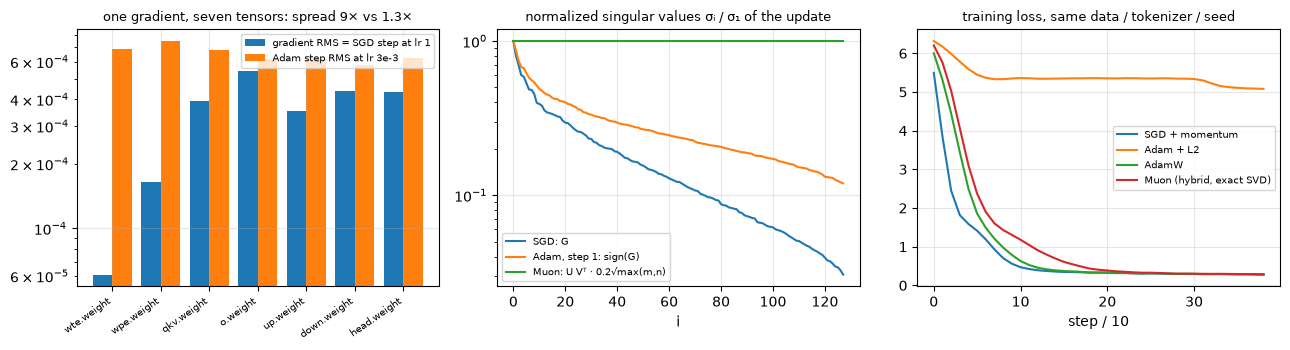

→ out\08_optimizers.png


In [37]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
xs = range(len(names))
ax[0].bar([i - 0.2 for i in xs], grad_rms, 0.4, label="gradient RMS = SGD step at lr 1")
ax[0].bar([i + 0.2 for i in xs], adam_rms, 0.4, label="Adam step RMS at lr 3e-3")
ax[0].set_yscale("log"); ax[0].set_xticks(list(xs)); ax[0].set_xticklabels(names, rotation=35, ha="right", fontsize=7)
ax[0].set_title("one gradient, seven tensors: spread 9× vs 1.3×", fontsize=9); ax[0].legend(fontsize=7)
for name, s in spectra.items():
    ax[1].plot(s, label=name)
ax[1].set_yscale("log"); ax[1].set_title("normalized singular values σᵢ / σ₁ of the update", fontsize=9); ax[1].legend(fontsize=7); ax[1].set_xlabel("i")
for name, r in results.items():
    ax[2].plot([sum(r["losses"][i:i + 20]) / 20 for i in range(0, STEPS - 19, 10)], label=name)
ax[2].set_title("training loss, same data / tokenizer / seed", fontsize=9); ax[2].set_xlabel("step / 10"); ax[2].legend(fontsize=7)
for a in ax:
    a.grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "08_optimizers.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"→ {OUT / '08_optimizers.png'}")

The three observations below are ordered from most to least reliable.

**Weight decay.** `Adam + L2` and `AdamW` share every hyperparameter, including
`weight_decay=0.1`, and one of them does not train. Under L2 the term `0.1 · p` is ten times
the gradient of this model (section 2: gradients of order `1e-4`, weights of order `1e-2`), so
after division by `√v` the update is `lr · sign(p)` toward zero on every coordinate: the weights
collapse to a norm of a few tenths and the loss stays at the unigram level. Under AdamW the
same value shrinks the weights by `3e-4 · p` per step and training is normal. With an L2
coefficient two orders of magnitude smaller, Adam + L2 trains again. The same number means
different things in the two algorithms, and production configs use AdamW.

**Step time.** Here Muon's step is an SVD of eight matrices, and the table shows its cost
relative to AdamW's element-wise passes. On a 7B model it would be an SVD of hundreds of
`4096 × 11008` matrices per step, which is too expensive. In practice five Newton–Schulz
iterations in bf16 are used instead.

**The ranking of the curves** is the least reliable: one seed, 400 steps, half a million
parameters, and a corpus that a two-layer model nearly memorizes. Tuned SGD ends up close to
AdamW here, since this model has a norm in front of every matrix and a gradient spread of only
nine. The SGD sweep also shows the cost of tuning: the largest learning rate leads for a
hundred steps and then diverges. Wen et al. tuned every optimizer carefully and found the
matrix-based ones ahead of AdamW by 1.4× at 0.1B parameters and 1.1× at 1.2B: a moderate gain
that shrinks with scale. A fair comparison of optimizers reports loss per token, loss per
wall-clock second, and memory.

## 5. The hybrid split

Muon is always used together with AdamW, and the split is not simply `ndim == 2`.
Orthogonalizing an embedding table makes little sense, since its rows are looked up rather
than multiplied; the LM head plays the same role on the output side; and 1-D parameters have
no spectrum. These stay on AdamW, and every 2-D weight inside the blocks goes
to Muon. A correct split puts every trainable parameter in exactly one group, with no overlap
and no duplication of tied parameters.

In [38]:
model = TinyGPT(tok.get_vocab_size())
to_muon = [(n, tuple(p.shape)) for n, p in model.named_parameters() if p.ndim == 2 and n.startswith("blocks.")]
to_adam = [(n, tuple(p.shape)) for n, p in model.named_parameters() if not (p.ndim == 2 and n.startswith("blocks."))]
print(f"to Muon  ({sum(math.prod(s) for _, s in to_muon) / 1e3:.0f}k params): " + ", ".join(f"{n} {s}" for n, s in to_muon))
print(f"to AdamW ({sum(math.prod(s) for _, s in to_adam) / 1e3:.0f}k params): " + ", ".join(f"{n} {s}" for n, s in to_adam))

to Muon  (393k params): blocks.0.qkv.weight (384, 128), blocks.0.o.weight (128, 128), blocks.0.up.weight (512, 128), blocks.0.down.weight (128, 512), blocks.1.qkv.weight (384, 128), blocks.1.o.weight (128, 128), blocks.1.up.weight (512, 128), blocks.1.down.weight (128, 512)
to AdamW (139k params): wte.weight (512, 128), wpe.weight (64, 128), head.weight (512, 128)


Systems aspects not covered here:

1. **State.** Adam stores two buffers per parameter and Muon one. The saving of 4 bytes per
   parameter matters mostly for very large models.
2. **Sharding.** `U Vᵀ` needs the whole matrix. Under ZeRO-1 each matrix is split across `n`
   GPUs, which does not matter for the element-wise AdamW. Muon has to gather the matrix, let
   one rank compute and send the result back, or orthogonalize the pieces separately, which
   changes the algorithm. These options differ in exactness and cost.
3. **Comparison.** Optimizers should be compared on loss per token, loss per wall-clock second
   and memory, not on a single axis.

---

# 09 — `apply_chat_template`, with the magic removed

**Appendix.** The sections above produced token sequences for a base model. For SFT and
inference the data is a list of messages with roles. The model sees only tokens, so
`{"role": "user", "content": ...}` has to be turned into a flat string with control tokens in
the right places, deterministically and identically at training and at inference. This is done
by a **Jinja template stored inside the tokenizer**.

Below we build one on our own tokenizer, without downloading anything and without a model.

Runtime: a second. Dependencies: `tokenizers`, `transformers`, `jinja2`.

In [39]:
from __future__ import annotations

import json
import sys
from pathlib import Path

from tokenizers import Tokenizer, decoders, models, normalizers, pre_tokenizers, processors, trainers
from transformers import PreTrainedTokenizerFast

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
SPECIAL_TOKENS = ["<pad>", "<unk>", "<bos>", "<eos>"]
CONTROL_TOKENS = ["<|system|>", "<|user|>", "<|assistant|>"]

clean_path = OUT / "03_corpus_clean.jsonl"
texts = ([json.loads(l)["text"] for l in clean_path.open(encoding="utf-8")] if clean_path.exists()
         else ["Токенизатор переводит строку в последовательность целых идентификаторов.",
               "A tokenizer maps text into a sequence of integer identifiers."])

## 1. A tokenizer with BOS/EOS behaviour

The same recipe as above, plus a **post-processor** that wraps every encoded text in
`<bos> … <eos>`. Most real tokenizers have one, and it causes the common bug shown in section 3.

In [40]:
tok = Tokenizer(models.BPE(unk_token="<unk>"))
tok.normalizer = normalizers.NFKC()
tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tok.decoder = decoders.ByteLevel()
tok.train_from_iterator(texts, trainers.BpeTrainer(vocab_size=360, min_frequency=1,
                                                   special_tokens=SPECIAL_TOKENS + CONTROL_TOKENS,
                                                   show_progress=False))
bos, eos = tok.token_to_id("<bos>"), tok.token_to_id("<eos>")
tok.post_processor = processors.TemplateProcessing(
    single="<bos> $A <eos>", pair="<bos> $A <eos> $B <eos>",
    special_tokens=[("<bos>", bos), ("<eos>", eos)])

hf = PreTrainedTokenizerFast(tokenizer_object=tok, pad_token="<pad>", unk_token="<unk>",
                             bos_token="<bos>", eos_token="<eos>",
                             additional_special_tokens=CONTROL_TOKENS)
print("special ids:", {t: hf.convert_tokens_to_ids(t) for t in SPECIAL_TOKENS + CONTROL_TOKENS})
print("plain encode adds BOS/EOS:", hf("привет").input_ids)

special ids: {'<pad>': 0, '<unk>': 1, '<bos>': 2, '<eos>': 3, '<|system|>': 4, '<|user|>': 5, '<|assistant|>': 6}
plain encode adds BOS/EOS: [2, 181, 121, 118, 160, 139, 3]


## 2. The template is a program

Nine lines of Jinja. For every message: the role's control token, a newline, the content,
EOS, a newline. Then, **only if requested**, the opening control token of the assistant, so
that generation starts inside an assistant turn. This last branch is the difference between a
training example and an inference prompt.

In [41]:
hf.chat_template = """{%- for message in messages %}
{{- '<|' + message['role'] + '|>\\n' }}
{{- message['content'] + eos_token + '\\n' }}
{%- endfor %}
{%- if add_generation_prompt %}
{{- '<|assistant|>\\n' }}
{%- endif %}"""

DIALOGUE = [
    {"role": "system", "content": "Отвечай кратко и проверяй размерности."},
    {"role": "user", "content": "Какой shape у causal attention mask?"},
    {"role": "assistant", "content": "Она broadcast-совместима с [batch, heads, query, key]."},
]

training_text = hf.apply_chat_template(DIALOGUE, tokenize=False, add_generation_prompt=False)
prompt_text = hf.apply_chat_template(DIALOGUE[:-1], tokenize=False, add_generation_prompt=True)

print("TRAINING serialization — the full dialogue, no open turn at the end:")
print(training_text)
print("INFERENCE serialization — the prompt, ending in an OPEN assistant turn:")
print(prompt_text)
assert prompt_text.endswith("<|assistant|>\n")

TRAINING serialization — the full dialogue, no open turn at the end:
<|system|>
Отвечай кратко и проверяй размерности.<eos>
<|user|>
Какой shape у causal attention mask?<eos>
<|assistant|>
Она broadcast-совместима с [batch, heads, query, key].<eos>

INFERENCE serialization — the prompt, ending in an OPEN assistant turn:
<|system|>
Отвечай кратко и проверяй размерности.<eos>
<|user|>
Какой shape у causal attention mask?<eos>
<|assistant|>



## 3. From string to ids, and why `tokenize=True` is the safer path

The template returned a string. The model needs ids. `apply_chat_template(tokenize=True)`
does both steps and knows **not** to add the tokenizer's own BOS/EOS around the whole thing.
Do the two steps by hand and forget that, and you get a `<bos>` the model was never trained
to see at that position — and a doubled `<eos>` at the end.

In [42]:
ids_direct = hf.apply_chat_template(DIALOGUE[:-1], tokenize=True, add_generation_prompt=True,
                                    return_dict=True)["input_ids"]
ids_naive = hf(prompt_text).input_ids                              # the bug: post-processor fires again
ids_correct = hf(prompt_text, add_special_tokens=False).input_ids  # the fix

print("ids, tokenize=True          :", ids_direct[:8], "…", ids_direct[-4:], f"({len(ids_direct)} tokens)")
print("ids, string then hf(text)   :", ids_naive[:8], "…", ids_naive[-4:], f"({len(ids_naive)} tokens)  ← extra <bos>, extra <eos>")
print("ids, add_special_tokens=False:", ids_correct[:8], "…", ids_correct[-4:], f"({len(ids_correct)} tokens)")
assert ids_direct == ids_correct and len(ids_naive) == len(ids_direct) + 2

enc = tok.encode(prompt_text, add_special_tokens=False)
groups = []  # merge tokens whose character spans overlap (byte-level splits inside one character)
for s, e in enc.offsets:
    if e <= s:
        continue
    if groups and s < groups[-1][1]:
        groups[-1][1], groups[-1][2] = max(groups[-1][1], e), groups[-1][2] + 1
    else:
        groups.append([s, e, 1])
print("\nthe first tokens, as spans of the serialized text (×k = that span took k tokens):")
print("  " + " ".join(repr(prompt_text[s:e].replace("\n", "⏎")) + (f"×{k}" if k > 1 else "")
                      for s, e, k in groups[:14]))

ids, tokenize=True          : [4, 87, 84, 110, 119, 160, 115, 151] … [3, 87, 6, 87] (58 tokens)
ids, string then hf(text)   : [2, 4, 87, 84, 110, 119, 160, 115] … [87, 6, 87, 3] (60 tokens)  ← extra <bos>, extra <eos>
ids, add_special_tokens=False: [4, 87, 84, 110, 119, 160, 115, 151] … [3, 87, 6, 87] (58 tokens)

the first tokens, as spans of the serialized text (×k = that span took k tokens):
  '<|system|>' '⏎' 'О'×2 'т' 'в' 'е' 'ч' 'ай'×2 ' к' 'р' 'ат' 'к' 'о' ' и'


The row starts with `<|system|>`, a newline, then the text in the same byte-level pieces as
before. For the model, roles exist only as these control tokens.

## 4. Where the boundary sits

* a pretraining document is **not** wrapped into a fake user turn. It is a document;
  the template belongs to SFT data and to inference prompts, nowhere earlier;
* a training example is the full dialogue with `add_generation_prompt=False`; an
  inference prompt stops before the answer with `add_generation_prompt=True`;
* the template belongs to **the model**. The template of a different chat model produces
  fluent text with wrong control tokens, and nothing crashes. Since transformers 4.34 the
  template ships inside `tokenizer_config.json` and `apply_chat_template` reads it from there;
* which of these tokens get a loss and which are masked out is response masking, part of SFT.
  The `{% generation %}` block that modern templates use for it lives in the same Jinja file.

In [43]:
print("as stored in tokenizer_config.json, the template is one string field:")
print(json.dumps({"chat_template": hf.chat_template}, ensure_ascii=False, indent=2)[:400], "…")

as stored in tokenizer_config.json, the template is one string field:
{
  "chat_template": "{%- for message in messages %}\n{{- '<|' + message['role'] + '|>\\n' }}\n{{- message['content'] + eos_token + '\\n' }}\n{%- endfor %}\n{%- if add_generation_prompt %}\n{{- '<|assistant|>\\n' }}\n{%- endif %}"
} …
